# App-30 — Ordonnancement d'assemblage orbital
## Le certificat, pas seulement le chiffre : encodage lexicographique, comparaison appariée, front d'échange

**Navigation** : [Index Applications](../README.md) | [Série Search](../../README.md) | [CSP-4 Scheduling](../../Part2-CSP/CSP-4-Scheduling.ipynb) | [App-29 SALBP](App-29-SALBP-AssemblyLineBalancing-Audit.ipynb)

> **Hommage à Gurvan Estable, Joris Bely et Kévin Lubert — projet C4, EPITA SCIA 2026.** Leur projet n'a pas traité l'assemblage orbital comme un ordonnancement d'atelier déguisé. Il a fait descendre la physique dans le modèle : les durées de manœuvre viennent d'un temps de vol de Hohmann réellement calculé, les coûts viennent d'un Δv réellement calculé, et le budget d'ergol contraint les mêmes intervalles que les couloirs orbitaux. Coupler ainsi la décision temporelle et la décision énergétique dans un unique modèle CP-SAT — au lieu de fixer des durées arbitraires — est le geste central de cette distillation.

Un plan d'assemblage orbital ressemble à un diagramme de Gantt. Il n'en est pas un. Allonger une poussée n'est pas seulement « prendre plus de temps » : c'est basculer sur un profil de propulsion plus économe, donc modifier le carburant consommé, donc modifier ce que les autres manœuvres pourront encore se permettre. Le temps et l'ergol ne sont pas deux colonnes d'un tableau : ce sont deux faces de la même décision.

Ce couplage rend la lecture des résultats plus délicate qu'il n'y paraît. Un plan qui finit plus tôt **et** consomme moins n'est pas forcément meilleur « des deux côtés » : il peut simplement avoir été comparé à un adversaire qui, lui, courait après une autre cible. Une moyenne de pourcentages sur des instances hétérogènes peut inverser le signe de l'effet qu'elle prétend résumer. Et un solveur qui répond `FEASIBLE` ne dit pas la même chose selon la manière dont on lui a écrit l'objectif.

CoursIA reconstruit donc ici un appareil indépendant pour répondre à des questions plus exigeantes que « quel makespan le solveur affiche-t-il ? » :

1. **Que modélise-t-on ?** Deux profils de propulsion par poussée, des couloirs exclusifs, des fenêtres d'accès, un budget d'ergol et une capacité de débit concurrent.
2. **Que vérifie-t-on ?** Un plan candidat, relu par un auditeur qui ne partage aucun état avec le solveur qui l'a produit.
3. **Qu'écrit-on exactement ?** Deux encodages de « d'abord le makespan, ensuite l'ergol » — et la preuve qu'ils définissent le **même** optimum.
4. **Que compare-t-on ?** Deux plans à makespan égal, plutôt que deux plans qui ne visaient pas la même chose.
5. **Que coûte la priorité ?** Le front d'échange makespan ↔ ergol, point par point, avec le statut de chacun.
6. **Où le certificat cède-t-il ?** Une sonde en taille **et** en densité de disjonctions, au-delà de la grille publiée.

Le notebook est entièrement offline et déterministe. Il ne copie ni module, ni cellule, ni prose, ni figure du projet C4 : il en préserve la question et la prolonge dans un registre de **niveaux de preuve**. La discrétisation est délibérément différente de celle du rendu source, afin qu'aucun chiffre produit ici ne puisse être confondu avec les siens.

**Parcours (~70 min)** — physique orbitale → domaine et débit → générateur identifiable → auditeur externe → deux encodages et preuve d'exactitude → concordance → statistiques appariées → comparaison à makespan égal → front d'échange → sonde de difficulté → exercices → hommage et bilan.

## 1. L'atelier orbital — pourquoi la physique doit entrer dans le modèle

Un ordonnancement classique reçoit ses durées comme des données. Ici, elles se **calculent**. Déplacer un module d'une orbite circulaire à une autre par un transfert de Hohmann impose simultanément :

- un coût énergétique **Δv**, somme des deux impulsions (départ et circularisation) ;
- une durée de vol égale à la demi-période de l'ellipse de transfert.

Ces deux grandeurs sont liées par la même géométrie : on ne peut pas choisir l'une sans subir l'autre. C'est précisément ce que le projet C4 a refusé de simplifier, et c'est ce que cette application conserve.

Les constantes ci-dessous fixent la **discrétisation CoursIA** : un créneau vaut 900 s (15 min) et une unité d'ergol vaut 5 m/s. Ce choix est volontairement distinct de celui du rendu source, pour que les grandeurs des deux travaux restent non confondables.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import platform
import statistics as st
import sys
import time
from dataclasses import dataclass
from itertools import product
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import ortools
from ortools.sat.python import cp_model

DATA_DIR = Path("data/app30-orbital-assembly-audit")
if not DATA_DIR.exists():
    DATA_DIR = Path("MyIA.AI.Notebooks/Search/Applications/Hybrid/data/app30-orbital-assembly-audit")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# --- Constantes canoniques a deux corps ---
MU_EARTH = 3.986_004_418e14        # m^3 / s^2, parametre gravitationnel terrestre
R_EARTH = 6_378_137.0              # m, rayon equatorial
SLOT_SECONDS = 900                 # discretisation CoursIA : 15 min par creneau
DV_UNIT_MPS = 5.0                  # 1 unite d'ergol = 5 m/s


def orbital_radius_m(altitude_km):
    return R_EARTH + altitude_km * 1_000.0


def circular_speed_mps(radius_m):
    return math.sqrt(MU_EARTH / radius_m)


def hohmann_delta_v_mps(r1, r2):
    """Somme des deux impulsions d'un transfert de Hohmann entre orbites circulaires."""
    v1, v2 = circular_speed_mps(r1), circular_speed_mps(r2)
    dv_depart = v1 * (math.sqrt(2.0 * r2 / (r1 + r2)) - 1.0)
    dv_arrive = v2 * (1.0 - math.sqrt(2.0 * r1 / (r1 + r2)))
    return abs(dv_depart) + abs(dv_arrive)


def hohmann_flight_time_s(r1, r2):
    """Demi-periode de l'ellipse de transfert : la duree n'est pas un parametre libre."""
    semi_major = 0.5 * (r1 + r2)
    return math.pi * math.sqrt(semi_major ** 3 / MU_EARTH)


def orbital_period_s(radius_m):
    return 2.0 * math.pi * math.sqrt(radius_m ** 3 / MU_EARTH)


def to_slots(seconds):
    return max(1, int(math.ceil(seconds / SLOT_SECONDS)))


def to_dv_units(delta_v_mps):
    return max(1, int(math.ceil(delta_v_mps / DV_UNIT_MPS)))


ENV = {
    "python": sys.version.split()[0],
    "ortools": ortools.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "slot_seconds": SLOT_SECONDS,
    "dv_unit_mps": DV_UNIT_MPS,
}
print("Environnement de collecte :")
for k, v in ENV.items():
    print(f"  {k:>14} : {v}")

rows = []
for label, a_km, b_km in [("rehaussement LEO", 420.0, 780.0),
                          ("LEO -> MEO", 780.0, 4_200.0),
                          ("phasage LEO", 400.0, 540.0)]:
    r1, r2 = orbital_radius_m(a_km), orbital_radius_m(b_km)
    dv = hohmann_delta_v_mps(r1, r2)
    tof = hohmann_flight_time_s(r1, r2)
    rows.append({"manoeuvre": label, "alt_depart_km": a_km, "alt_arrivee_km": b_km,
                 "delta_v_m_s": round(dv, 1), "temps_de_vol_min": round(tof / 60.0, 1),
                 "creneaux": to_slots(tof), "unites_ergol": to_dv_units(dv)})
print("\nTrois transferts, calcules et non postules :")
print(pd.DataFrame(rows).to_string(index=False))

Environnement de collecte :
          python : 3.13.14
         ortools : 9.15.6755
          pandas : 2.3.3
      matplotlib : 3.10.8
        platform : Windows-11-10.0.26200-SP0
    slot_seconds : 900
     dv_unit_mps : 5.0

Trois transferts, calcules et non postules :
       manoeuvre  alt_depart_km  alt_arrivee_km  delta_v_m_s  temps_de_vol_min  creneaux  unites_ergol
rehaussement LEO          420.0           780.0        195.0              48.3         4            40
      LEO -> MEO          780.0          4200.0       1311.3              69.3         5           263
     phasage LEO          400.0           540.0         78.0              47.0         4            16


### Ce que le tableau impose au modèle

Les trois manœuvres ne se rangent pas dans le même ordre selon le critère. Le passage LEO → MEO est de loin le plus cher en Δv, et c'est aussi le plus long : ici, coût et durée vont dans le même sens. Mais le phasage LEO et le rehaussement LEO sont proches en durée alors que leurs Δv diffèrent nettement. **Un ordonnanceur qui ne regarderait que les durées traiterait ces deux manœuvres comme presque interchangeables** — alors qu'elles ne le sont pas du tout pour le budget d'ergol.

C'est l'argument qui justifie de coupler les deux décisions dans un seul modèle plutôt que d'ordonnancer d'abord et de compter le carburant ensuite. Le projet C4 a fait ce choix, et l'appareil CoursIA le conserve intégralement.

Après conversion, les durées tombent dans une poignée de créneaux. Ce plancher de discrétisation aura son importance : un effet plus petit qu'un créneau est **invisible pour le modèle**, quelle que soit sa réalité physique. Nous y reviendrons quand il s'agira de mesurer un écart de makespan.

## 2. Le domaine — une poussée, deux profils, un **débit**

Chaque module demande deux poussées : un **transfert** qui l'amène à son orbite de travail, puis un **amarrage**, manœuvre de proximité dont la durée est gouvernée par la période orbitale de la cible.

Chaque poussée est planifiable sous **deux profils** exclusifs :

- profil **rapide** (`hi`) — moins de créneaux, plus d'ergol ;
- profil **économe** (`lo`) — plus de créneaux, moins d'ergol.

C'est ce choix binaire qui crée le couplage : le solveur ne décide pas seulement *quand*, il décide *comment*, et les deux décisions se paient mutuellement.

Un point de modélisation mérite d'être explicité plutôt que subi. La ressource partagée — puissance de station, capacité de ravitaillement, personnel d'opération — est consommée pendant toute la durée de la poussée. La grandeur qui doit entrer dans une contrainte cumulative est donc un **débit** (unités d'ergol par créneau), pas l'impulsion totale. Une contrainte cumulative dont la hauteur serait un Δv total et la largeur une durée additionnerait des grandeurs de dimensions différentes. Nous prenons ici la lecture homogène, et nous le disons.

In [2]:
@dataclass(frozen=True)
class Burn:
    """Une poussee planifiable : transfert orbital ou amarrage."""
    idx: int
    module: str
    step: str          # "transfert" | "amarrage"
    regime: str
    corridor: int
    alt_from_km: float
    alt_to_km: float
    access_open: int
    access_close: int
    slots_hi: int      # profil rapide : plus court, plus couteux
    slots_lo: int      # profil econome : plus long, plus sobre
    dv_hi: int
    dv_lo: int

    @property
    def label(self):
        return f"{self.module}/{self.step}"

    @property
    def span_min(self):
        return min(self.slots_hi, self.slots_lo)

    @property
    def span_max(self):
        return max(self.slots_hi, self.slots_lo)

    @property
    def rate_hi(self):
        """Debit d'ergol du profil rapide, en unites par creneau."""
        return max(1, int(math.ceil(self.dv_hi / self.slots_hi)))

    @property
    def rate_lo(self):
        return max(1, int(math.ceil(self.dv_lo / self.slots_lo)))


@dataclass(frozen=True)
class AssemblyInstance:
    name: str
    horizon: int
    burns: List[Burn]
    precedences: List[Tuple[int, int, int]]     # (avant, apres, delai)
    separations: List[Tuple[int, int, int]]     # (a, b, ecart) — disjonction
    propellant_budget: int
    concurrent_rate_cap: int
    meta: Dict[str, object]

    def size(self):
        return len(self.burns)

    def identity_digest(self):
        """Identite STRUCTURELLE : le nom d'une instance n'est jamais une preuve."""
        payload = {
            "burns": [[b.idx, b.corridor, b.access_open, b.access_close,
                       b.slots_hi, b.slots_lo, b.dv_hi, b.dv_lo] for b in self.burns],
            "precedences": sorted(self.precedences),
            "separations": sorted(self.separations),
            "budget": self.propellant_budget,
            "cap": self.concurrent_rate_cap,
            "horizon": self.horizon,
        }
        blob = json.dumps(payload, sort_keys=True, separators=(",", ":"))
        return hashlib.sha256(blob.encode("utf-8")).hexdigest()


demo = Burn(idx=0, module="M00", step="transfert", regime="leo_vers_meo", corridor=0,
            alt_from_km=780.0, alt_to_km=4200.0, access_open=0, access_close=60,
            slots_hi=4, slots_lo=7, dv_hi=180, dv_lo=130)
print("Une poussee, deux profils :")
print(f"  rapide  : {demo.slots_hi} creneaux, {demo.dv_hi} unites d'ergol,"
      f" debit {demo.rate_hi} u/creneau")
print(f"  econome : {demo.slots_lo} creneaux, {demo.dv_lo} unites d'ergol,"
      f" debit {demo.rate_lo} u/creneau")
print(f"\n  ecart de duree  : +{demo.slots_lo - demo.slots_hi} creneaux (+{100*(demo.slots_lo-demo.slots_hi)/demo.slots_hi:.0f} %)")
print(f"  ecart d'ergol   : {demo.dv_lo - demo.dv_hi} unites ({100*(demo.dv_lo-demo.dv_hi)/demo.dv_hi:+.0f} %)")
print(f"  ecart de debit  : {demo.rate_lo - demo.rate_hi} u/creneau ({100*(demo.rate_lo-demo.rate_hi)/demo.rate_hi:+.0f} %)")

Une poussee, deux profils :
  rapide  : 4 creneaux, 180 unites d'ergol, debit 45 u/creneau
  econome : 7 creneaux, 130 unites d'ergol, debit 19 u/creneau

  ecart de duree  : +3 creneaux (+75 %)
  ecart d'ergol   : -50 unites (-28 %)
  ecart de debit  : -26 u/creneau (-58 %)


### Le débit est ce qui rend le compromis non trivial

Le profil économe consomme **moins d'ergol au total** et occupe **moins de ressource par créneau**. Sur ces deux plans, il domine. S'il ne s'imposait pas partout, ce serait incompréhensible.

Ce qui l'empêche de s'imposer, c'est la seule chose qu'il dégrade : il occupe le couloir orbital **plus longtemps**. Or les couloirs sont exclusifs. Chaque créneau supplémentaire passé par une poussée en profil économe est un créneau où aucune autre poussée du même couloir ne peut avancer. L'arbitrage n'est donc pas « vitesse contre carburant » pris isolément sur une manœuvre : c'est « carburant contre *congestion du couloir* », et il ne se résout qu'au niveau du plan complet.

C'est exactement le genre d'interaction qu'une règle gloutonne — qui décide poussée par poussée — ne peut pas anticiper, et qu'un modèle global peut trancher.

## 3. Le générateur — des instances qui portent leur identité

Les instances sont produites par un générateur déterministe interne (congruentiel linéaire explicite, sans dépendance à l'état global de `random`). Deux exécutions du notebook, sur deux machines, produisent les mêmes instances.

La topologie est celle d'une campagne d'assemblage réaliste dans sa structure :

- une paire *transfert → amarrage* par module, avec un délai de décantation ;
- un **module clé de voûte** dont l'amarrage précède tous les autres ;
- des **couloirs orbitaux exclusifs**, propriété du module : ses deux poussées empruntent la même voie ;
- des **écarts de sécurité** entre amarrages de couloirs distincts — des disjonctions, donc le vrai moteur de difficulté combinatoire ;
- des fenêtres d'accès, un budget d'ergol global et une capacité de débit concurrent.

Le paramètre `separation_density` contrôle la proportion de paires d'amarrages soumises à un écart de sécurité. Il sera notre second axe de difficulté, à côté de la taille.

In [3]:
_PROFILES = (
    ("rehaussement_leo", 420.0, 780.0),
    ("leo_vers_meo", 780.0, 4_200.0),
    ("phasage_leo", 400.0, 540.0),
)


def generate_instance(n_modules=6, seed=0, separation_density=0.12):
    """Campagne d'assemblage deterministe. LCG interne : aucune dependance globale."""
    state = (seed * 6_364_136_223_846_793_005 + 1_442_695_040_888_963_407) % (2 ** 61)

    def draw(lo, hi):
        nonlocal state
        state = (state * 6_364_136_223_846_793_005 + 1_442_695_040_888_963_407) % (2 ** 61)
        return lo + (state >> 17) % max(1, hi - lo + 1)

    horizon = 96 + 22 * n_modules
    n_corridors = max(2, math.ceil(n_modules / 3))
    burns, precedences = [], []

    for m in range(n_modules):
        regime, alt_a, alt_b = _PROFILES[m % len(_PROFILES)]
        alt_a += draw(0, 60)
        alt_b += draw(0, 90)
        r1, r2 = orbital_radius_m(alt_a), orbital_radius_m(alt_b)

        dv_transfer = hohmann_delta_v_mps(r1, r2)
        tof_transfer = hohmann_flight_time_s(r1, r2)
        # L'amarrage est une manoeuvre de proximite : faible dv, duree gouvernee
        # par la periode orbitale de l'orbite cible.
        dv_berth = 0.055 * dv_transfer + 4.0
        tof_berth = 0.32 * orbital_period_s(r2)

        for step, dv_ref, tof_ref in (("transfert", dv_transfer, tof_transfer),
                                      ("amarrage", dv_berth, tof_berth)):
            idx = len(burns)
            slots_hi = to_slots(tof_ref)
            slots_lo = slots_hi + max(1, int(round(0.55 * slots_hi))) + draw(0, 2)
            dv_lo = to_dv_units(dv_ref)
            dv_hi = dv_lo + max(1, int(round(0.38 * dv_lo))) + draw(0, 2)

            open_at = draw(0, max(1, horizon // 4))
            width = slots_lo + draw(int(0.9 * horizon) // 3, int(0.9 * horizon) // 2)
            close_at = min(horizon, open_at + width)
            if close_at - open_at < slots_lo + 2:
                close_at = min(horizon, open_at + slots_lo + 2)

            burns.append(Burn(
                idx=idx, module=f"M{m:02d}", step=step, regime=regime,
                # Le couloir est une propriete du MODULE : ses deux poussees
                # empruntent la meme voie exclusive.
                corridor=m % n_corridors,
                alt_from_km=alt_a if step == "transfert" else alt_b, alt_to_km=alt_b,
                access_open=open_at, access_close=close_at,
                slots_hi=slots_hi, slots_lo=slots_lo, dv_hi=dv_hi, dv_lo=dv_lo))

        transfer_idx, berth_idx = 2 * m, 2 * m + 1
        precedences.append((transfer_idx, berth_idx, 1))   # decantation avant amarrage
        if m > 0:
            precedences.append((1, berth_idx, 0))          # cle de voute d'abord

    separations = []
    berthings = [b for b in burns if b.step == "amarrage"]
    for left, right in product(berthings, berthings):
        if left.idx >= right.idx or left.corridor == right.corridor:
            continue
        if draw(0, 999) < int(separation_density * 1000):
            separations.append((left.idx, right.idx, 1))

    min_total = sum(b.dv_lo for b in burns)
    max_total = sum(b.dv_hi for b in burns)
    propellant_budget = min_total + int(round(0.55 * (max_total - min_total)))
    rates = [b.rate_hi for b in burns]
    concurrent_rate_cap = max(rates) + int(round(1.3 * (sum(rates) / len(rates))))

    return AssemblyInstance(
        name=f"coursia-orbital-m{n_modules}-s{seed}", horizon=horizon, burns=burns,
        precedences=precedences, separations=separations,
        propellant_budget=propellant_budget, concurrent_rate_cap=concurrent_rate_cap,
        meta={"n_modules": n_modules, "seed": seed, "n_corridors": n_corridors,
              "slot_seconds": SLOT_SECONDS, "dv_unit_mps": DV_UNIT_MPS,
              "separation_density": separation_density})


REF = generate_instance(n_modules=6, seed=11, separation_density=0.25)
print(f"Instance de reference : {REF.name}")
print(f"  poussees {REF.size()} | horizon {REF.horizon} creneaux | "
      f"couloirs {REF.meta['n_corridors']}")
print(f"  precedences {len(REF.precedences)} | ecarts de securite {len(REF.separations)}")
print(f"  budget d'ergol {REF.propellant_budget} u | capacite de debit "
      f"{REF.concurrent_rate_cap} u/creneau")
print(f"  empreinte d'identite : {REF.identity_digest()[:32]}...")

print("\nLes six premieres poussees :")
print(pd.DataFrame([{"idx": b.idx, "poussee": b.label, "couloir": b.corridor,
                     "fenetre": f"[{b.access_open},{b.access_close}]",
                     "rapide": f"{b.slots_hi}cr/{b.dv_hi}u", "debit_hi": b.rate_hi,
                     "econome": f"{b.slots_lo}cr/{b.dv_lo}u", "debit_lo": b.rate_lo}
                    for b in REF.burns[:6]]).to_string(index=False))

# Determinisme : deux appels independants doivent donner la meme empreinte.
assert generate_instance(6, 11, 0.25).identity_digest() == REF.identity_digest()
print("\nDeterminisme verifie : deux constructions independantes, meme empreinte.")

Instance de reference : coursia-orbital-m6-s11
  poussees 12 | horizon 228 creneaux | couloirs 2
  precedences 11 | ecarts de securite 4
  budget d'ergol 818 u | capacite de debit 94 u/creneau
  empreinte d'identite : 9561a6bad9f3485d526b01c678090c09...

Les six premieres poussees :


 idx       poussee  couloir  fenetre   rapide  debit_hi  econome  debit_lo
   0 M00/transfert        0 [39,130]  4cr/52u        13  8cr/37u         5
   1  M00/amarrage        0 [18,126]   3cr/6u         2   7cr/3u         1
   2 M01/transfert        1 [48,154] 5cr/359u        72 9cr/260u        29
   3  M01/amarrage        1 [53,144]  4cr/22u         6  8cr/16u         2
   4 M02/transfert        0 [26,106]  4cr/21u         6  7cr/15u         3
   5  M02/amarrage        0 [38,125]   3cr/3u         1   5cr/2u         1

Determinisme verifie : deux constructions independantes, meme empreinte.


### Le nom n'est pas une clé, l'empreinte l'est

`coursia-orbital-m6-s11` est une étiquette commode. Elle ne prouve rien. Deux instances portant ce nom, produites par deux versions du générateur, seraient différentes sans que rien ne l'annonce — et tout écart mesuré entre elles serait ininterprétable.

L'empreinte SHA-256 couvre la structure complète : couloirs, fenêtres, durées et coûts des deux profils, précédences et séparations triées, budget, capacité et horizon. C'est elle qui autorise — ou refuse — de rapprocher deux mesures. Le contrat est écrit dans `data/app30-orbital-assembly-audit/SOURCE.md` : **aucune grandeur de cette application n'est comparée à une grandeur externe sans égalité d'empreinte**. C'est aussi la raison pour laquelle les chiffres produits ici ne sont pas comparables à ceux du rendu source, dont la discrétisation diffère : ce sont d'autres instances, et nous refusons de les agréger.

## 4. Un auditeur qui ne doit rien au solveur

Voici la question qui gouverne cette section : **qui valide le validateur ?**

Un plan peut être vérifié par du code appelé par le composant qui l'a produit. C'est confortable et cela ne prouve presque rien : si le producteur et le vérificateur partagent la même interprétation d'une contrainte, ils partagent aussi la même erreur, et le taux de validité observé vaut alors 100 % par construction. Le chiffre est vrai ; il est simplement vide. On mesure la cohérence interne d'un composant, pas la validité de son résultat.

L'auditeur ci-dessous est écrit **à partir des seules sémantiques de contraintes**, sans réutiliser la moindre structure des solveurs, et il n'est appelé par aucun d'eux pour établir leur propre faisabilité. Deux détails de conception le rendent utilisable comme oracle :

- il **signale toutes les fautes**, jamais seulement la première — un plan qui viole cinq contraintes est un renseignement, un plan qui « viole quelque chose » n'en est pas un ;
- il vérifie la capacité concurrente par **balayage événementiel** en `O(n log n)` sur les seuls instants de changement, au lieu de parcourir l'horizon créneau par créneau.

Nous le mettons immédiatement à l'épreuve sur un plan délibérément corrompu : un auditeur qu'on n'a jamais vu échouer n'a pas encore été testé.

In [4]:
def audit_plan(instance, plan):
    """Oracle externe : ne partage aucun etat avec les solveurs.

    Signale l'integralite des fautes, jamais la premiere.
    """
    if not plan:
        return {"valid": False, "faults": ["plan vide"], "n_faults": 1}

    faults, rows = [], {int(r["idx"]): r for r in plan}
    expected, seen = set(range(instance.size())), set(rows)
    for missing in sorted(expected - seen):
        faults.append(f"poussee absente : {missing}")
    for extra in sorted(seen - expected):
        faults.append(f"poussee inconnue : {extra}")
    if len(plan) != len(rows):
        faults.append("indices dupliques dans le plan")

    for idx in sorted(seen & expected):
        row, burn = rows[idx], instance.burns[idx]
        start, end, profile = int(row["start"]), int(row["end"]), str(row["profile"])
        if profile == "hi":
            span, dv, rate = burn.slots_hi, burn.dv_hi, burn.rate_hi
        elif profile == "lo":
            span, dv, rate = burn.slots_lo, burn.dv_lo, burn.rate_lo
        else:
            faults.append(f"profil inconnu pour {idx} : {profile}")
            continue
        if end - start != span:
            faults.append(f"duree incoherente pour {idx}")
        if int(row["dv"]) != dv:
            faults.append(f"ergol incoherent avec le profil pour {idx}")
        if int(row["rate"]) != rate:
            faults.append(f"debit incoherent avec le profil pour {idx}")
        if start < burn.access_open:
            faults.append(f"ouverture de fenetre violee pour {idx}")
        if end > burn.access_close:
            faults.append(f"fermeture de fenetre violee pour {idx}")

    # Exclusivite des couloirs, par balayage trie.
    by_corridor = {}
    for idx in sorted(seen & expected):
        by_corridor.setdefault(instance.burns[idx].corridor, []).append(
            (int(rows[idx]["start"]), int(rows[idx]["end"]), idx))
    for corridor, items in by_corridor.items():
        items.sort()
        for (s1, e1, i1), (s2, e2, i2) in zip(items, items[1:]):
            if e1 > s2:
                faults.append(f"couloir {corridor} : chevauchement {i1}/{i2}")

    for before, after, lag in instance.precedences:
        if before in rows and after in rows:
            if int(rows[before]["end"]) + lag > int(rows[after]["start"]):
                faults.append(f"precedence violee {before}->{after} (delai {lag})")

    for a, b, gap in instance.separations:
        if a in rows and b in rows:
            a_first = int(rows[a]["end"]) + gap <= int(rows[b]["start"])
            b_first = int(rows[b]["end"]) + gap <= int(rows[a]["start"])
            if not (a_first or b_first):
                faults.append(f"ecart de securite viole {a}<->{b}")

    total = sum(int(r["dv"]) for r in plan)
    if total > instance.propellant_budget:
        faults.append(f"budget d'ergol depasse : {total} > {instance.propellant_budget}")

    # Capacite concurrente : balayage evenementiel O(n log n).
    events = []
    for r in plan:
        events.append((int(r["start"]), int(r["rate"])))
        events.append((int(r["end"]), -int(r["rate"])))
    events.sort()
    load = 0
    for position, delta in events:
        load += delta
        if load > instance.concurrent_rate_cap:
            faults.append(f"capacite concurrente depassee a t={position} : "
                          f"{load} > {instance.concurrent_rate_cap}")

    makespan = max(int(r["end"]) for r in plan) if plan else None
    return {"valid": not faults, "faults": faults, "n_faults": len(faults),
            "makespan": makespan, "propellant": total}


# Epreuve de l'auditeur : un plan volontairement corrompu de trois facons.
naif = [{"idx": b.idx, "start": b.access_open, "end": b.access_open + b.slots_hi,
         "profile": "hi", "dv": b.dv_hi, "rate": b.rate_hi} for b in REF.burns]
verdict = audit_plan(REF, naif)
print(f"Plan naif (tout au plus tot, profil rapide) : valide = {verdict['valid']}, "
      f"{verdict['n_faults']} faute(s)")
for f in verdict["faults"][:6]:
    print("   -", f)
if verdict["n_faults"] > 6:
    print(f"   ... et {verdict['n_faults'] - 6} autre(s)")

familles = sorted({f.split(" ")[0] + " " + f.split(" ")[1] for f in verdict["faults"]})
print(f"\nL'auditeur distingue {len(familles)} familles de fautes sur ce seul plan.")
print("Un auditeur qui s'arreterait a la premiere n'en aurait signale qu'une.")

Plan naif (tout au plus tot, profil rapide) : valide = False, 7 faute(s)
   - couloir 0 : chevauchement 5/0
   - couloir 1 : chevauchement 11/7
   - precedence violee 0->1 (delai 1)
   - precedence violee 2->3 (delai 1)
   - precedence violee 8->9 (delai 1)
   - ecart de securite viole 5<->7
   ... et 1 autre(s)

L'auditeur distingue 5 familles de fautes sur ce seul plan.
Un auditeur qui s'arreterait a la premiere n'en aurait signale qu'une.


### Ce que l'indépendance de l'oracle rend possible

Le plan naïf échoue, et il échoue de plusieurs façons simultanées. C'est la propriété recherchée : un diagnostic, pas un verdict binaire.

L'intérêt méthodologique dépasse le débogage. À partir d'ici, chaque plan produit par chaque méthode de ce notebook — les deux encodages exacts, la règle de répartition, chaque point de front — passe devant cet auditeur. Quand nous écrirons « la règle de répartition produit des plans valides », ce sera une mesure indépendante et non une reformulation de sa propre logique interne.

Le coût de cette indépendance est réel : l'auditeur duplique volontairement la sémantique des contraintes. Cette duplication est le prix du test. La partager avec le solveur reviendrait à supprimer le test tout en conservant le tableau de résultats.

## 5. Deux écritures de « d'abord le makespan, ensuite l'ergol »

L'objectif est lexicographique : minimiser le makespan d'abord, puis, **à makespan optimal**, minimiser l'ergol. Deux écritures s'offrent naturellement.

**A — scalarisation pondérée.** Un seul modèle, un seul objectif :

$$\min\; \text{makespan} \times (B+1) + \text{ergol}$$

où $B$ est le budget d'ergol, donc $0 \le \text{ergol} \le B$.

**B — deux passes.** Minimiser le makespan ; fixer $\text{makespan} \le mk^{\star}$ ; minimiser l'ergol.

Ces deux écritures ne sont pas concurrentes par leur résultat — nous allons le prouver, puis le vérifier. Elles diffèrent par ce qu'elles **rendent lisible** quand le temps manque.

In [5]:
def _build_model(instance):
    """Modele CP-SAT commun aux deux encodages et au front d'echange."""
    model = cp_model.CpModel()
    n = instance.size()
    starts, ends, spans, dvs, rates, hi_flags, intervals = {}, {}, {}, {}, {}, {}, {}
    by_corridor = {}

    for i, burn in enumerate(instance.burns):
        lo_bound, hi_bound = burn.access_open, burn.access_close - burn.span_min
        if lo_bound > hi_bound:
            return None, None
        starts[i] = model.NewIntVar(lo_bound, hi_bound, f"s{i}")
        ends[i] = model.NewIntVar(lo_bound + burn.span_min, burn.access_close, f"e{i}")
        spans[i] = model.NewIntVar(burn.span_min, burn.span_max, f"d{i}")
        dvs[i] = model.NewIntVar(min(burn.dv_lo, burn.dv_hi),
                                 max(burn.dv_lo, burn.dv_hi), f"v{i}")
        rates[i] = model.NewIntVar(min(burn.rate_lo, burn.rate_hi),
                                   max(burn.rate_lo, burn.rate_hi), f"r{i}")
        hi_flags[i] = model.NewBoolVar(f"hi{i}")

        # Le profil est un choix binaire : duree, ergol et debit basculent ensemble.
        model.Add(spans[i] == burn.slots_hi).OnlyEnforceIf(hi_flags[i])
        model.Add(dvs[i] == burn.dv_hi).OnlyEnforceIf(hi_flags[i])
        model.Add(rates[i] == burn.rate_hi).OnlyEnforceIf(hi_flags[i])
        model.Add(spans[i] == burn.slots_lo).OnlyEnforceIf(hi_flags[i].Not())
        model.Add(dvs[i] == burn.dv_lo).OnlyEnforceIf(hi_flags[i].Not())
        model.Add(rates[i] == burn.rate_lo).OnlyEnforceIf(hi_flags[i].Not())

        intervals[i] = model.NewIntervalVar(starts[i], spans[i], ends[i], f"itv{i}")
        by_corridor.setdefault(burn.corridor, []).append(intervals[i])

    for corridor_intervals in by_corridor.values():
        if len(corridor_intervals) >= 2:
            model.AddNoOverlap(corridor_intervals)

    for before, after, lag in instance.precedences:
        model.Add(ends[before] + lag <= starts[after])

    for a, b, gap in instance.separations:
        a_first = model.NewBoolVar(f"sep{a}_{b}")
        model.Add(ends[a] + gap <= starts[b]).OnlyEnforceIf(a_first)
        model.Add(ends[b] + gap <= starts[a]).OnlyEnforceIf(a_first.Not())

    propellant = model.NewIntVar(0, instance.propellant_budget, "propellant")
    model.Add(propellant == sum(dvs[i] for i in range(n)))

    # Cumulative a demande de DEBIT : hauteur et largeur restent homogenes.
    model.AddCumulative([intervals[i] for i in range(n)],
                        [rates[i] for i in range(n)], instance.concurrent_rate_cap)

    makespan = model.NewIntVar(0, instance.horizon, "makespan")
    model.AddMaxEquality(makespan, [ends[i] for i in range(n)])

    return model, {"starts": starts, "ends": ends, "spans": spans, "dvs": dvs,
                   "rates": rates, "hi": hi_flags, "propellant": propellant,
                   "makespan": makespan}


def _extract_plan(solver, instance, h):
    return [{"idx": i, "label": b.label, "module": b.module, "step": b.step,
             "corridor": b.corridor, "regime": b.regime,
             "profile": "hi" if solver.Value(h["hi"][i]) == 1 else "lo",
             "start": solver.Value(h["starts"][i]), "end": solver.Value(h["ends"][i]),
             "span": solver.Value(h["spans"][i]), "dv": solver.Value(h["dvs"][i]),
             "rate": solver.Value(h["rates"][i])}
            for i, b in enumerate(instance.burns)]


def _configure(time_limit_s, workers, seed):
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit_s
    solver.parameters.num_search_workers = workers
    solver.parameters.random_seed = seed
    return solver


def solve_weighted(instance, time_limit_s=20.0, workers=8, seed=0):
    """Encodage A : un seul modele, objectif scalarise par grand coefficient."""
    model, h = _build_model(instance)
    if model is None:
        return {"strategy": "ponderee", "status": "FENETRE_VIDE", "feasible": False}
    weight = instance.propellant_budget + 1
    upper = instance.horizon * weight + instance.propellant_budget
    objective = model.NewIntVar(0, upper, "objective")
    model.Add(objective == h["makespan"] * weight + h["propellant"])
    model.Minimize(objective)

    solver = _configure(time_limit_s, workers, seed)
    t0 = time.perf_counter()
    status = solver.Solve(model)
    elapsed = time.perf_counter() - t0
    name = solver.StatusName(status)
    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return {"strategy": "ponderee", "status": name, "feasible": False,
                "wall_s": elapsed}
    return {"strategy": "ponderee", "status": name, "feasible": True,
            "makespan": int(solver.Value(h["makespan"])),
            "propellant": int(solver.Value(h["propellant"])),
            "objective": int(solver.Value(objective)), "weight": weight,
            "objective_domain": upper, "wall_s": elapsed,
            "conflicts": solver.NumConflicts(), "branches": solver.NumBranches(),
            "plan": _extract_plan(solver, instance, h)}


def solve_two_pass(instance, time_limit_s=20.0, workers=8, seed=0):
    """Encodage B : deux passes, donc DEUX certificats independants."""
    model, h = _build_model(instance)
    if model is None:
        return {"strategy": "deux_passes", "status": "FENETRE_VIDE", "feasible": False}
    model.Minimize(h["makespan"])
    solver = _configure(time_limit_s, workers, seed)
    t0 = time.perf_counter()
    status_a = solver.Solve(model)
    elapsed_a = time.perf_counter() - t0
    name_a = solver.StatusName(status_a)
    if status_a not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return {"strategy": "deux_passes", "status": name_a, "feasible": False,
                "wall_s": elapsed_a}
    best_makespan = int(solver.Value(h["makespan"]))
    stats_a = {"status": name_a, "wall_s": elapsed_a,
               "conflicts": solver.NumConflicts(), "branches": solver.NumBranches()}

    model2, h2 = _build_model(instance)
    model2.Add(h2["makespan"] <= best_makespan)
    model2.Minimize(h2["propellant"])
    solver2 = _configure(time_limit_s, workers, seed)
    t1 = time.perf_counter()
    status_b = solver2.Solve(model2)
    elapsed_b = time.perf_counter() - t1
    name_b = solver2.StatusName(status_b)
    if status_b not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return {"strategy": "deux_passes", "status": f"{name_a}/{name_b}",
                "feasible": False, "wall_s": elapsed_a + elapsed_b}
    return {"strategy": "deux_passes", "status": f"{name_a}/{name_b}",
            "certified": name_a == "OPTIMAL" and name_b == "OPTIMAL",
            "makespan_certified": name_a == "OPTIMAL", "feasible": True,
            "makespan": int(solver2.Value(h2["makespan"])),
            "propellant": int(solver2.Value(h2["propellant"])),
            "wall_s": elapsed_a + elapsed_b, "pass_makespan": stats_a,
            "pass_propellant": {"status": name_b, "wall_s": elapsed_b,
                                "conflicts": solver2.NumConflicts()},
            "plan": _extract_plan(solver2, instance, h2)}


def exchange_front(instance, best_makespan, relaxations, time_limit_s=20.0,
                   workers=8, seed=0):
    """epsilon-contrainte : meilleur ergol atteignable sous makespan <= mk* + eps."""
    points = []
    for eps in relaxations:
        cap = min(instance.horizon, best_makespan + eps)
        model, h = _build_model(instance)
        model.Add(h["makespan"] <= cap)
        model.Minimize(h["propellant"])
        solver = _configure(time_limit_s, workers, seed)
        t0 = time.perf_counter()
        status = solver.Solve(model)
        elapsed = time.perf_counter() - t0
        name = solver.StatusName(status)
        if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
            points.append({"eps": eps, "cap": cap, "status": name, "feasible": False,
                           "wall_s": elapsed})
            continue
        points.append({"eps": eps, "cap": cap, "status": name, "feasible": True,
                       "certified": name == "OPTIMAL",
                       "makespan": int(solver.Value(h["makespan"])),
                       "propellant": int(solver.Value(h["propellant"])),
                       "wall_s": elapsed, "plan": _extract_plan(solver, instance, h)})
    return points


print("Modele et encodages definis.")
print(f"Instance {REF.name} : poids de scalarisation B+1 = {REF.propellant_budget + 1}")

Modele et encodages definis.
Instance coursia-orbital-m6-s11 : poids de scalarisation B+1 = 819


### La scalarisation n'est pas une approximation : elle est **exactement** lexicographique

On lit souvent qu'un objectif du type $mk \times W + f$ « approxime » une priorité lexicographique, avec un poids $W$ choisi « assez grand ». Ici, le choix $W = B+1$ rend l'énoncé **exact**, et cela se démontre en trois lignes.

Soient deux plans $A$ et $B$ réalisables, d'ergols $f_A, f_B$ nécessairement dans $[0, B]$ puisque le budget est une contrainte du modèle. Supposons $mk_A < mk_B$, c'est-à-dire $mk_A + 1 \le mk_B$ (les makespans sont entiers). Alors :

$$\text{obj}_A = mk_A(B+1) + f_A \;\le\; mk_A(B+1) + B \;<\; mk_A(B+1) + (B+1) \;=\; (mk_A+1)(B+1) \;\le\; mk_B(B+1) \;\le\; \text{obj}_B$$

Donc $mk_A < mk_B \Rightarrow \text{obj}_A < \text{obj}_B$ : **aucune économie d'ergol, si grande soit-elle, ne peut compenser un créneau de makespan.** Et à makespan égal, $\text{obj}_A - \text{obj}_B = f_A - f_B$ : le départage se fait exactement sur l'ergol. L'ordre induit par l'objectif scalarisé *est* l'ordre lexicographique.

La condition qui rend la preuve valide mérite d'être isolée, car c'est elle qui peut se perdre : il faut que **le budget soit une contrainte du modèle**, sans quoi $f$ n'est plus borné par $B$ et l'inégalité stricte tombe. Ici `propellant` est déclarée sur $[0, B]$ — la borne est structurelle, pas une hypothèse de bonne conduite.

Les deux encodages définissent donc le **même** optimum. Ils ne diffèrent ni en exactitude ni en valeur : uniquement par le certificat qu'ils savent rendre quand la recherche est interrompue. C'est ce que les sections 6 et 10 vont mesurer.

## 6. E1 — les deux encodages coïncident-ils, et à quel prix ?

La preuve précédente est un énoncé mathématique ; elle mérite une vérification empirique indépendante. Nous résolvons 25 instances (5 tailles × 5 graines) avec les deux encodages, plus une **règle de répartition** — un glouton au plus tôt, profil rapide préféré, qui servira de référence constructive dans les sections suivantes.

Chaque plan produit, par n'importe laquelle des trois méthodes, passe devant l'auditeur externe.

In [6]:
def _dispatch_ok(instance, placed, i, start, end, rate):
    """Verification incrementale interne a la regle de repartition."""
    burn = instance.burns[i]
    if start < burn.access_open or end > burn.access_close:
        return False
    for j, row in placed.items():
        if instance.burns[j].corridor == burn.corridor:
            if not (end <= row["start"] or row["end"] <= start):
                return False
    for a, b, gap in instance.separations:
        other = b if a == i else (a if b == i else None)
        if other is None or other not in placed:
            continue
        row = placed[other]
        if not (end + gap <= row["start"] or row["end"] + gap <= start):
            return False
    events = [(start, rate), (end, -rate)]
    for row in placed.values():
        events += [(row["start"], row["rate"]), (row["end"], -row["rate"])]
    events.sort()
    load = 0
    for _, delta in events:
        load += delta
        if load > instance.concurrent_rate_cap:
            return False
    return True


def solve_dispatch(instance):
    """Regle de repartition : au plus tot, profil rapide prefere.

    Borne superieure constructive, jamais exacte. Elle traite les poussees dans
    un ordre topologique trie par fermeture de fenetre, et reserve pour les
    poussees restantes leur consommation minimale : sans cette reserve, une
    regle qui prefere le profil rapide epuise le budget avant la fin du plan.
    """
    t0 = time.perf_counter()
    n = instance.size()
    successors, indegree = {}, [0] * n
    for before, after, lag in instance.precedences:
        successors.setdefault(before, []).append((after, lag))
        indegree[after] += 1

    order, pending = [], sorted([i for i in range(n) if indegree[i] == 0],
                                key=lambda i: (instance.burns[i].access_close, i))
    while pending:
        i = pending.pop(0)
        order.append(i)
        for after, lag in successors.get(i, []):
            indegree[after] -= 1
            if indegree[after] == 0:
                pending.append(after)
                pending.sort(key=lambda j: (instance.burns[j].access_close, j))
    if len(order) != n:
        return {"strategy": "repartition", "status": "CYCLE", "feasible": False,
                "wall_s": time.perf_counter() - t0}

    # Reserve : consommation minimale de tout ce qui reste apres i.
    floor_lookup, reste = {}, 0
    for i in reversed(order):
        floor_lookup[i] = reste
        reste += min(instance.burns[i].dv_lo, instance.burns[i].dv_hi)

    placed, used = {}, 0
    for i in order:
        burn = instance.burns[i]
        earliest = burn.access_open
        for before, after, lag in instance.precedences:
            if after == i and before in placed:
                earliest = max(earliest, placed[before]["end"] + lag)

        chosen = None
        for profile, span, dv, rate in (
                ("hi", burn.slots_hi, burn.dv_hi, burn.rate_hi),
                ("lo", burn.slots_lo, burn.dv_lo, burn.rate_lo)):
            if used + dv + floor_lookup[i] > instance.propellant_budget:
                continue                       # ce profil condamnerait la suite
            for t in range(earliest, burn.access_close - span + 1):
                if _dispatch_ok(instance, placed, i, t, t + span, rate):
                    chosen = {"idx": i, "label": burn.label, "module": burn.module,
                              "step": burn.step, "corridor": burn.corridor,
                              "regime": burn.regime, "profile": profile,
                              "start": t, "end": t + span, "span": span,
                              "dv": dv, "rate": rate}
                    break
            if chosen:
                break
        if chosen is None:
            return {"strategy": "repartition", "status": "ECHEC", "feasible": False,
                    "bloque_sur": burn.label, "wall_s": time.perf_counter() - t0}
        placed[i] = chosen
        used += chosen["dv"]

    plan = sorted(placed.values(), key=lambda r: r["idx"])
    return {"strategy": "repartition", "status": "FAISABLE", "feasible": True,
            "makespan": max(r["end"] for r in plan),
            "propellant": sum(r["dv"] for r in plan),
            "wall_s": time.perf_counter() - t0, "plan": plan}


SIZES, SEEDS, DENSITY = [4, 6, 8, 10, 12], [11, 22, 33, 44, 55], 0.25
grid = []
for n in SIZES:
    for s in SEEDS:
        inst = generate_instance(n_modules=n, seed=s, separation_density=DENSITY)
        w = solve_weighted(inst, time_limit_s=20.0, seed=s)
        t = solve_two_pass(inst, time_limit_s=20.0, seed=s)
        g = solve_dispatch(inst)
        grid.append({
            "instance": inst.name, "n_modules": n, "seed": s, "n_burns": inst.size(),
            "horizon": inst.horizon, "corridors": inst.meta["n_corridors"],
            "separations": len(inst.separations), "budget": inst.propellant_budget,
            "digest": inst.identity_digest()[:16],
            "pond_status": w["status"], "pond_mk": w["makespan"],
            "pond_fuel": w["propellant"], "pond_wall_s": round(w["wall_s"], 4),
            "pond_conflicts": w["conflicts"], "pond_domaine_objectif": w["objective_domain"],
            "2p_status": t["status"], "2p_mk": t["makespan"], "2p_fuel": t["propellant"],
            "2p_wall_s": round(t["wall_s"], 4), "2p_certifie": t["certified"],
            "disp_status": g["status"], "disp_mk": g.get("makespan"),
            "disp_fuel": g.get("propellant"), "disp_wall_s": round(g["wall_s"], 4),
            "audit_pond": audit_plan(inst, w.get("plan"))["valid"],
            "audit_2p": audit_plan(inst, t.get("plan"))["valid"],
            "audit_disp": audit_plan(inst, g.get("plan"))["valid"],
        })

GRID = pd.DataFrame(grid)
GRID.to_csv(DATA_DIR / "grid_runs.csv", index=False)

accord = int((GRID["pond_mk"].eq(GRID["2p_mk"]) & GRID["pond_fuel"].eq(GRID["2p_fuel"])).sum())
print(f"Instances : {len(GRID)}")
print(f"Couples (makespan, ergol) identiques entre les deux encodages : {accord}/{len(GRID)}")
print(f"Certificats OPTIMAL sur les deux passes : {int(GRID['2p_certifie'].sum())}/{len(GRID)}")
print(f"Statuts ponderes OPTIMAL : {int((GRID['pond_status'] == 'OPTIMAL').sum())}/{len(GRID)}")
print(f"\nDomaine de l'objectif scalarise : {GRID['pond_domaine_objectif'].min()} "
      f"a {GRID['pond_domaine_objectif'].max()}")
print(f"Temps total  pondere {GRID['pond_wall_s'].sum():.3f} s "
      f"| deux passes {GRID['2p_wall_s'].sum():.3f} s "
      f"(x{GRID['2p_wall_s'].sum() / GRID['pond_wall_s'].sum():.2f})")
print(f"Audits externes en echec : "
      f"{int((~GRID[['audit_pond', 'audit_2p', 'audit_disp']].all(axis=1)).sum())}")
print("\nExtrait :")
print(GRID[["instance", "n_burns", "separations", "pond_status", "pond_mk", "pond_fuel",
            "2p_status", "2p_mk", "2p_fuel", "disp_mk", "disp_fuel"]].head(8).to_string(index=False))

Instances : 25
Couples (makespan, ergol) identiques entre les deux encodages : 25/25
Certificats OPTIMAL sur les deux passes : 25/25
Statuts ponderes OPTIMAL : 25/25

Domaine de l'objectif scalarise : 85469 a 604313
Temps total  pondere 1.617 s | deux passes 2.903 s (x1.80)
Audits externes en echec : 0

Extrait :
              instance  n_burns  separations pond_status  pond_mk  pond_fuel       2p_status  2p_mk  2p_fuel  disp_mk  disp_fuel
coursia-orbital-m4-s11        8            0     OPTIMAL       51        408 OPTIMAL/OPTIMAL     51      408       52        433
coursia-orbital-m4-s22        8            1     OPTIMAL       56        442 OPTIMAL/OPTIMAL     56      442       56        448
coursia-orbital-m4-s33        8            1     OPTIMAL       37        421 OPTIMAL/OPTIMAL     37      421       41        444
coursia-orbital-m4-s44        8            0     OPTIMAL       59        406 OPTIMAL/OPTIMAL     59      406       59        429
coursia-orbital-m4-s55        8         

### Lecture — la coïncidence n'en est pas une

**25/25 couples (makespan, ergol) identiques** entre les deux encodages. Ce n'est pas une observation heureuse : c'est la preuve de la section 5 qui se manifeste. Si un seul couple avait divergé, c'est la preuve qu'il aurait fallu reprendre, pas les solveurs.

Les deux encodages certifient tout sur cette grille : 25/25 `OPTIMAL` pour l'encodage pondéré, 25/25 `OPTIMAL/OPTIMAL` pour les deux passes. Quand tout est certifié, le second encodage n'apporte aucune information supplémentaire — et il coûte **1,80 fois** le temps du premier (2,903 s contre 1,617 s cumulées). Sur une grille facile, la scalarisation est le bon choix, sans réserve. La section 10 ira chercher le régime où ce jugement s'inverse.

Deux détails valent d'être relevés.

Le **domaine de l'objectif scalarisé** s'étend ici de 85 469 à 604 313. Ce sont des entiers parfaitement représentables, et c'est justement ce qu'il faut vérifier avant d'employer un grand coefficient : la preuve d'exactitude suppose une arithmétique entière sans débordement. Sur des budgets ou des horizons beaucoup plus grands, l'énoncé resterait vrai en mathématiques et deviendrait fragile en machine — le poids `B+1` multiplie l'horizon.

L'**auditeur externe n'a rejeté aucun des 75 plans** produits par les trois méthodes. C'est un renseignement, pas une formalité : l'auditeur vient de démontrer en section 4 qu'il sait échouer. Un oracle qui n'échoue jamais, sur aucune entrée, ne prouve rien ; celui-ci a déjà rejeté un plan avant d'accepter ceux-là.

## 7. E2 — un écart moyen n'est pas encore un résultat

Comparons maintenant la règle de répartition au modèle exact. La tentation est d'annoncer un gain moyen en pourcentage et de passer à la suite. Trois précautions changent pourtant l'interprétation.

**Première précaution : la dispersion.** Une moyenne sans écart-type ni extrêmes ne dit pas si l'effet est systématique ou porté par quelques instances.

**Deuxième précaution : un test apparié.** Les instances ne sont pas des répétitions d'une même expérience ; chacune a sa propre difficulté. Ce qui se teste, c'est le **signe de l'écart instance par instance**. Nous utilisons deux tests exacts, sans hypothèse de normalité : le test des signes (binomial) et le Wilcoxon signé, énuméré exactement tant que l'effectif le permet.

**Troisième précaution : la dominance.** Deux critères peuvent aller en sens contraires. Il faut compter séparément les instances où le modèle exact domine sur les deux critères et celles où les deux méthodes sont Pareto-incomparables.

In [7]:
def _binom_tail(k, n):
    """P(X <= k) pour X ~ Binomiale(n, 1/2), calcul exact."""
    return sum(math.comb(n, i) for i in range(k + 1)) / (2 ** n)


def sign_test(deltas):
    """Test des signes bilateral exact (binomial), les ex aequo sont ecartes."""
    pos = sum(1 for d in deltas if d > 0)
    neg = sum(1 for d in deltas if d < 0)
    ties = sum(1 for d in deltas if d == 0)
    n = pos + neg
    if n == 0:
        return {"positifs": pos, "negatifs": neg, "ex_aequo": ties, "p": 1.0}
    p = min(1.0, 2.0 * _binom_tail(min(pos, neg), n))
    return {"positifs": pos, "negatifs": neg, "ex_aequo": ties, "p": p}


def wilcoxon_signed_rank(deltas):
    """Wilcoxon signe : enumeration EXACTE si n <= 22, sinon approximation normale."""
    vals = [d for d in deltas if d != 0]
    n = len(vals)
    if n == 0:
        return {"n": 0, "W": None, "p": 1.0, "methode": "aucun ecart non nul"}
    order = sorted(range(n), key=lambda i: abs(vals[i]))
    ranks = [0.0] * n
    i = 0
    while i < n:                      # rangs moyens sur les ex aequo d'amplitude
        j = i
        while j + 1 < n and abs(vals[order[j + 1]]) == abs(vals[order[i]]):
            j += 1
        moyen = (i + j) / 2.0 + 1.0
        for k in range(i, j + 1):
            ranks[order[k]] = moyen
        i = j + 1
    w_plus = sum(ranks[i] for i in range(n) if vals[i] > 0)
    w_minus = sum(ranks[i] for i in range(n) if vals[i] < 0)
    w = min(w_plus, w_minus)

    if n <= 22:                       # enumeration exacte des 2^n configurations
        total_ranks = [int(round(r)) for r in ranks]
        atteignables = {0: 1}
        for r in total_ranks:
            suivant = {}
            for somme, compte in atteignables.items():
                suivant[somme] = suivant.get(somme, 0) + compte
                suivant[somme + r] = suivant.get(somme + r, 0) + compte
            atteignables = suivant
        total = 2 ** n
        cumul = sum(c for s, c in atteignables.items() if s <= w)
        return {"n": n, "W": w, "p": min(1.0, 2.0 * cumul / total), "methode": "exact"}

    mu = n * (n + 1) / 4.0
    sigma = math.sqrt(n * (n + 1) * (2 * n + 1) / 24.0)
    z = (w - mu) / sigma
    p = math.erfc(abs(z) / math.sqrt(2.0))
    return {"n": n, "W": w, "p": min(1.0, p), "methode": "approximation normale", "z": z}


mk_delta = (GRID["disp_mk"] - GRID["pond_mk"]).tolist()
fu_delta = (GRID["disp_fuel"] - GRID["pond_fuel"]).tolist()

print("Ecart de makespan (repartition - exact), en creneaux :")
print(f"  min {min(mk_delta)}  mediane {st.median(mk_delta)}  max {max(mk_delta)}  "
      f"moyenne {st.mean(mk_delta):.2f}  ecart-type {st.pstdev(mk_delta):.2f}")
print("Ecart d'ergol (repartition - exact), en unites :")
print(f"  min {min(fu_delta)}  mediane {st.median(fu_delta)}  max {max(fu_delta)}  "
      f"moyenne {st.mean(fu_delta):.2f}  ecart-type {st.pstdev(fu_delta):.2f}")

print("\nTests apparies exacts :")
print("  signes   makespan :", sign_test(mk_delta))
print("  signes   ergol    :", sign_test(fu_delta))
print("  wilcoxon makespan :", wilcoxon_signed_rank(mk_delta))
print("  wilcoxon ergol    :", wilcoxon_signed_rank(fu_delta))

domine = incomparable = 0
details = []
for _, r in GRID.iterrows():
    mk_ok, fu_ok = r["pond_mk"] <= r["disp_mk"], r["pond_fuel"] <= r["disp_fuel"]
    if mk_ok and fu_ok:
        domine += 1
    elif mk_ok != fu_ok:
        incomparable += 1
        details.append(r)
print(f"\nLe modele exact domine sur les DEUX criteres : {domine}/{len(GRID)}")
print(f"Points Pareto-INCOMPARABLES : {incomparable}/{len(GRID)}")
for r in details:
    print(f"   {r['instance']} : exact ({r['pond_mk']}, {r['pond_fuel']})  "
          f"contre repartition ({r['disp_mk']}, {r['disp_fuel']})")

Ecart de makespan (repartition - exact), en creneaux :
  min 0  mediane 4  max 30  moyenne 7.40  ecart-type 7.52
Ecart d'ergol (repartition - exact), en unites :
  min -50  mediane 73  max 283  moyenne 108.32  ecart-type 92.63

Tests apparies exacts :
  signes   makespan : {'positifs': 21, 'negatifs': 0, 'ex_aequo': 4, 'p': 9.5367431640625e-07}
  signes   ergol    : {'positifs': 24, 'negatifs': 1, 'ex_aequo': 0, 'p': 1.5497207641601562e-06}
  wilcoxon makespan : {'n': 21, 'W': 0, 'p': 9.5367431640625e-07, 'methode': 'exact'}
  wilcoxon ergol    : {'n': 25, 'W': 11.0, 'p': 4.573887605543732e-05, 'methode': 'approximation normale', 'z': -4.076397131617654}

Le modele exact domine sur les DEUX criteres : 24/25
Points Pareto-INCOMPARABLES : 1/25
   coursia-orbital-m6-s11 : exact (69, 789)  contre repartition (75, 739)


### Lecture — ce que la moyenne cachait, et ce qu'elle ne cachait pas

Les moyennes sont franches : la règle de répartition finit en moyenne 7,40 créneaux plus tard et consomme 108,32 unités d'ergol de plus. Les trois précautions annoncées changent pourtant ce qu'on a le droit d'en conclure.

**La dispersion est du même ordre que l'effet.** L'écart de makespan a un écart-type de 7,52 pour une moyenne de 7,40 ; celui d'ergol, 92,63 pour 108,32. Les extrêmes vont de 0 à 30 créneaux et de −50 à +283 unités. Une moyenne seule aurait suggéré un effet homogène ; il ne l'est pas.

**Les tests appariés tranchent quand même, et nettement.** Sur le makespan : 21 instances en faveur du modèle exact, **0 contre**, 4 ex aequo — au test des signes, p ≈ 9,5 × 10⁻⁷, et le Wilcoxon exact donne W = 0 avec la même p-valeur, puisqu'aucun rang ne va dans l'autre sens. Sur l'ergol : 24 contre 1, p ≈ 1,5 × 10⁻⁶.

Une transparence de méthode s'impose ici. Le Wilcoxon sur l'ergol affiche `méthode: approximation normale` : les 25 écarts sont tous non nuls, donc n = 25 dépasse le seuil de 22 au-delà duquel l'énumération exacte des 2ⁿ configurations devient coûteuse. Sa p-valeur (≈ 4,6 × 10⁻⁵) est approchée, là où celle du makespan (n = 21) est exacte. Les deux concluent dans le même sens ; l'une est un calcul, l'autre une approximation, et le notebook affiche laquelle est laquelle plutôt que de laisser croire à une garantie uniforme.

**La dominance n'est pas totale.** Le modèle exact domine sur les deux critères dans 24 cas sur 25. Le vingt-cinquième, `coursia-orbital-m6-s11`, est Pareto-**incomparable** : l'exact obtient (69, 789), la répartition (75, 739). La règle heuristique finit 6 créneaux plus tard **et consomme 50 unités de moins**. Aucune des deux ne domine l'autre.

C'est cette instance, seule contre vingt-quatre, qui rend la section suivante nécessaire. Elle montre que l'écart d'ergol mesuré ici ne mesure pas ce qu'on croit : le modèle exact a dépensé du carburant pour acheter du temps, parce que c'est exactement ce que l'ordre lexicographique lui demande. Comparer ces deux plans revient à comparer deux réponses à deux questions différentes.

## 8. E2b — comparer à makespan égal

Nous arrivons au point de méthode central de cette application.

Les deux plans comparés en section 7 ne visaient pas la même chose. Le modèle exact minimise le makespan **en priorité** ; il achète donc du temps avec de l'ergol chaque fois que c'est nécessaire. La règle de répartition, elle, place au plus tôt sans arbitrer globalement. Quand on lit l'écart d'ergol entre ces deux plans, on lit **deux effets superposés** : l'inefficacité propre de l'heuristique, et le surcoût que le modèle exact s'impose volontairement pour finir plus tôt. Ces deux effets vont en sens contraires, et rien ne garantit leur ordre de grandeur relatif.

La correction est directe et ne coûte qu'une résolution supplémentaire. Pour chaque instance, nous demandons au modèle exact le **meilleur ergol atteignable au makespan que la règle de répartition a effectivement obtenu**. Les deux plans visent alors la même échéance, et la différence d'ergol ne mesure plus qu'une seule chose.

Il faut annoncer ce que cette correction risque de produire : en retirant au modèle exact l'avantage de finir plus tôt, on lui retire aussi une raison de dépenser. La comparaison corrigée peut donc réduire — ou augmenter — l'écart mesuré. Nous ne le saurons qu'en le calculant.

In [8]:
matched = []
for _, r in GRID.iterrows():
    inst = generate_instance(n_modules=int(r["n_modules"]), seed=int(r["seed"]),
                             separation_density=DENSITY)
    # Meilleur ergol CERTIFIE au makespan atteint par la regle de repartition.
    pts = exchange_front(inst, int(r["disp_mk"]), [0], time_limit_s=20.0,
                         seed=int(r["seed"]))
    p = pts[0]
    audit = audit_plan(inst, p["plan"])["valid"] if p.get("feasible") else None
    matched.append({
        "instance": r["instance"], "n_modules": r["n_modules"], "seed": r["seed"],
        "lex_mk": r["pond_mk"], "lex_fuel": r["pond_fuel"],
        "disp_mk": r["disp_mk"], "disp_fuel": r["disp_fuel"],
        "apparie_mk": p.get("makespan"), "apparie_fuel": p.get("propellant"),
        "apparie_status": p["status"], "apparie_audit": audit,
        "lecture_melangee_pct": 100.0 * (r["disp_fuel"] - r["pond_fuel"]) / r["disp_fuel"],
        "lecture_appariee_pct": (100.0 * (r["disp_fuel"] - p["propellant"]) / r["disp_fuel"]
                                 if p.get("feasible") else None),
    })

MATCHED = pd.DataFrame(matched)
MATCHED.to_csv(DATA_DIR / "matched_comparison.csv", index=False)

melangee = MATCHED["lecture_melangee_pct"].tolist()
appariee = MATCHED["lecture_appariee_pct"].dropna().tolist()

print("Lecture MELANGEE (exact lexicographique contre repartition, makespans differents) :")
print(f"  moyenne {st.mean(melangee):6.2f} %  mediane {st.median(melangee):6.2f} %  "
      f"min {min(melangee):6.2f} %  max {max(melangee):6.2f} %  "
      f"ecart-type {st.pstdev(melangee):5.2f}")
print("Lecture A MAKESPAN EGAL (optimum certifie au makespan de la repartition) :")
print(f"  moyenne {st.mean(appariee):6.2f} %  mediane {st.median(appariee):6.2f} %  "
      f"min {min(appariee):6.2f} %  max {max(appariee):6.2f} %  "
      f"ecart-type {st.pstdev(appariee):5.2f}")

ecart = [a - b for a, b in zip(melangee, appariee)]
print(f"\nEcart entre les deux lectures : moyenne {st.mean(ecart):+.2f} points, "
      f"min {min(ecart):+.2f}, max {max(ecart):+.2f}")
print("  signes :", sign_test([int(round(1000 * d)) for d in ecart]))

neg_melangee = [x for x in melangee if x < 0]
neg_appariee = [x for x in appariee if x < 0]
print(f"\nInstances ou la lecture melangee affiche un gain NEGATIF : {len(neg_melangee)}")
print(f"Instances ou la lecture appariee affiche un gain NEGATIF : {len(neg_appariee)}")
print(f"Points apparies certifies OPTIMAL : "
      f"{int((MATCHED['apparie_status'] == 'OPTIMAL').sum())}/{len(MATCHED)}")
print(f"Audits externes en echec : {int((MATCHED['apparie_audit'] == False).sum())}")

pires = MATCHED.nsmallest(3, "lecture_melangee_pct")[
    ["instance", "lex_mk", "lex_fuel", "disp_mk", "disp_fuel", "apparie_fuel",
     "lecture_melangee_pct", "lecture_appariee_pct"]]
print("\nLes trois instances les plus defavorables a la lecture melangee :")
print(pires.to_string(index=False))

Lecture MELANGEE (exact lexicographique contre repartition, makespans differents) :
  moyenne   8.47 %  mediane   8.88 %  min  -6.77 %  max  16.96 %  ecart-type  5.89
Lecture A MAKESPAN EGAL (optimum certifie au makespan de la repartition) :
  moyenne  14.06 %  mediane  16.81 %  min   1.34 %  max  18.22 %  ecart-type  4.98

Ecart entre les deux lectures : moyenne -5.59 points, min -17.58, max +0.00
  signes : {'positifs': 0, 'negatifs': 19, 'ex_aequo': 6, 'p': 3.814697265625e-06}

Instances ou la lecture melangee affiche un gain NEGATIF : 1
Instances ou la lecture appariee affiche un gain NEGATIF : 0
Points apparies certifies OPTIMAL : 25/25
Audits externes en echec : 0

Les trois instances les plus defavorables a la lecture melangee :
              instance  lex_mk  lex_fuel  disp_mk  disp_fuel  apparie_fuel  lecture_melangee_pct  lecture_appariee_pct
coursia-orbital-m6-s11      69       789       75        739           681             -6.765900              7.848444
coursia-orbital-

### Lecture — la correction renforce la conclusion, au lieu de l'affaiblir

En section 8, j'ai écrit que la comparaison corrigée pouvait réduire *ou* augmenter l'écart mesuré, et qu'on ne le saurait qu'en le calculant. Voici le calcul.

| Lecture | Moyenne | Médiane | Minimum | Maximum | Écart-type |
|---|---|---|---|---|---|
| mélangée (makespans différents) | 8,47 % | 8,88 % | **−6,77 %** | 16,96 % | 5,89 |
| à makespan égal | **14,06 %** | 16,81 % | **+1,34 %** | 18,22 % | 4,98 |

L'écart entre les deux lectures est de **−5,59 points en moyenne**, jusqu'à −17,58 points, et il n'est favorable à la lecture mélangée sur **aucune** instance : 0 positif, 19 négatifs, 6 ex aequo. Les 25 points appariés sont tous certifiés `OPTIMAL`, et l'auditeur externe les valide tous. Un exercice plus loin dans le notebook vous demandera de retrouver la p-valeur exacte de ce décompte ; elle n'est volontairement pas donnée ici.

La lecture mélangée **sous-estimait donc systématiquement** l'avantage du modèle exact en ergol. C'est le sens de la correction qu'il faut retenir : elle ne fragilise pas la conclusion des travaux qui comparent un modèle exact à une heuristique, elle la **renforce**.

Le mécanisme se lit sur `coursia-orbital-m6-s11`, l'instance Pareto-incomparable de la section précédente. En lecture mélangée, elle affiche **−6,77 %** : la répartition semble *battre* le modèle exact sur l'ergol. À makespan égal, le même modèle exact atteint 681 unités au makespan 75 de la répartition, contre 739 pour elle — soit **+7,85 %** en sa faveur. Le signe s'inverse. Le −6,77 % ne mesurait pas une infériorité du modèle : il mesurait le prix que la priorité lexicographique lui fait payer pour finir 6 créneaux plus tôt.

`coursia-orbital-m6-s44` raconte la même histoire en plus spectaculaire : 0,48 % en lecture mélangée, **18,06 %** à makespan égal.

La dispersion baisse aussi (5,89 → 4,98) et le minimum passe de −6,77 % à +1,34 %. En retirant du signal un effet qui n'avait rien à y faire, on obtient un effet plus grand, plus homogène et de signe constant. C'est la signature d'une variable de confusion correctement éliminée.

## 9. E3 — ce que coûte réellement la priorité au makespan

La priorité lexicographique est un choix, pas une nécessité. Elle affirme qu'un créneau de makespan vaut plus que n'importe quelle économie d'ergol. Dans une campagne d'assemblage réelle, cette affirmation est parfois vraie — fenêtre de lancement, contrat, conjonction orbitale — et parfois beaucoup trop coûteuse.

Le **front d'échange** rend ce choix négociable au lieu de le laisser implicite. Pour un relâchement $\varepsilon$ accordé sur le makespan, on demande le meilleur ergol atteignable sous $mk \le mk^\star + \varepsilon$. Chaque point porte son propre statut : il n'est dit **certifié** que si sa résolution est `OPTIMAL`.

Un point de vocabulaire, parce qu'il se perd facilement : une courbe reliant des points observés n'est pas un front de Pareto certifié. Nous traçons les points, nous indiquons leur statut, et nous ne relions rien que nous n'ayons prouvé.

In [9]:
CAS = [(6, 11), (8, 22), (10, 44), (12, 33)]
RELAX = list(range(0, 25, 2))
fronts = {}

for n, s in CAS:
    inst = generate_instance(n_modules=n, seed=s, separation_density=DENSITY)
    base = solve_weighted(inst, time_limit_s=20.0, seed=s)
    disp = solve_dispatch(inst)
    pts = exchange_front(inst, base["makespan"], RELAX, time_limit_s=20.0, seed=s)
    for p in pts:
        if p.get("feasible"):
            p["audit_valid"] = audit_plan(inst, p["plan"])["valid"]
        p.pop("plan", None)
    fronts[inst.name] = {
        "digest": inst.identity_digest(), "budget": inst.propellant_budget,
        "lexico_mk": base["makespan"], "lexico_fuel": base["propellant"],
        "repartition_mk": disp.get("makespan"), "repartition_fuel": disp.get("propellant"),
        "points": pts}

    ref = base["propellant"]
    certifies = sum(1 for p in pts if p.get("certified"))
    gains = [100.0 * (ref - p["propellant"]) / ref for p in pts if p.get("feasible")]
    print(f"{inst.name} : point lexicographique ({base['makespan']}, {ref}) | "
          f"{certifies}/{len(pts)} points certifies | "
          f"economie maximale {max(gains):.2f} % pour +{RELAX[gains.index(max(gains))]} creneaux")

(DATA_DIR / "exchange_fronts.json").write_text(
    json.dumps(fronts, indent=2, ensure_ascii=False), encoding="utf-8")

print("\nDetail du premier cas :")
premier = list(fronts)[0]
ref = fronts[premier]["lexico_fuel"]
tbl = [{"eps": p["eps"], "plafond_mk": p["cap"], "makespan": p.get("makespan"),
        "ergol": p.get("propellant"),
        "economie_pct": round(100.0 * (ref - p["propellant"]) / ref, 2) if p.get("feasible") else None,
        "statut": p["status"], "certifie": p.get("certified"), "audit": p.get("audit_valid")}
       for p in fronts[premier]["points"]]
print(pd.DataFrame(tbl).to_string(index=False))

coursia-orbital-m6-s11 : point lexicographique (69, 789) | 13/13 points certifies | economie maximale 14.83 % pour +12 creneaux


coursia-orbital-m8-s22 : point lexicographique (89, 1136) | 13/13 points certifies | economie maximale 10.92 % pour +16 creneaux


coursia-orbital-m10-s44 : point lexicographique (99, 1109) | 13/13 points certifies | economie maximale 4.06 % pour +16 creneaux


coursia-orbital-m12-s33 : point lexicographique (114, 1413) | 13/13 points certifies | economie maximale 3.40 % pour +22 creneaux

Detail du premier cas :
 eps  plafond_mk  makespan  ergol  economie_pct  statut  certifie  audit
   0          69        69    789          0.00 OPTIMAL      True   True
   2          71        71    690         12.55 OPTIMAL      True   True
   4          73        73    684         13.31 OPTIMAL      True   True
   6          75        75    681         13.69 OPTIMAL      True   True
   8          77        77    676         14.32 OPTIMAL      True   True
  10          79        78    675         14.45 OPTIMAL      True   True
  12          81        80    672         14.83 OPTIMAL      True   True
  14          83        83    672         14.83 OPTIMAL      True   True
  16          85        85    672         14.83 OPTIMAL      True   True
  18          87        83    672         14.83 OPTIMAL      True   True
  20          89        83    672         

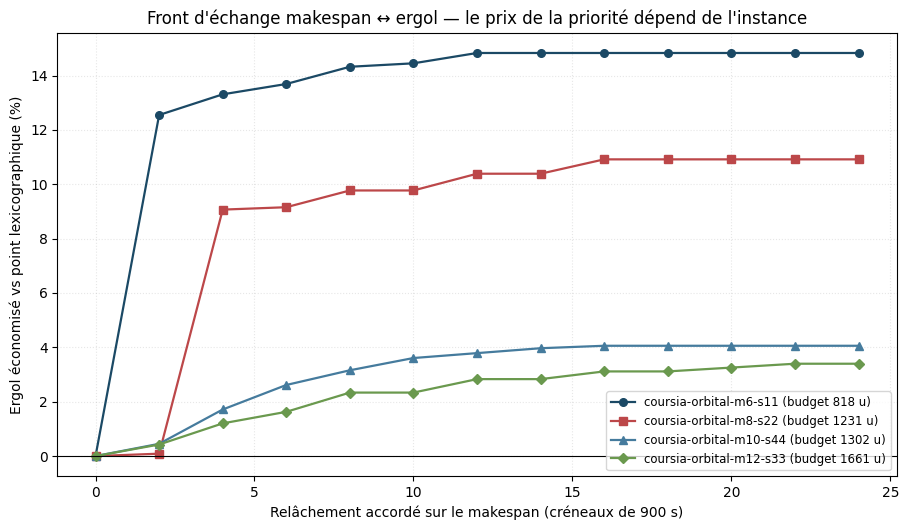

Pente initiale (economie gagnee par les 2 premiers creneaux relaches) :
  coursia-orbital-m6-s11       +2 creneaux -> 12.55 %   (saturation 14.83 %)
  coursia-orbital-m8-s22       +2 creneaux ->  0.09 %   (saturation 10.92 %)
  coursia-orbital-m10-s44      +2 creneaux ->  0.45 %   (saturation  4.06 %)
  coursia-orbital-m12-s33      +2 creneaux ->  0.42 %   (saturation  3.40 %)


In [10]:
fig, ax = plt.subplots(figsize=(9.2, 5.4))
marqueurs = ["o", "s", "^", "D"]
couleurs = ["#1b4965", "#bc4749", "#457b9d", "#6a994e"]

for k, (nom, bloc) in enumerate(fronts.items()):
    ref = bloc["lexico_fuel"]
    xs = [p["eps"] for p in bloc["points"] if p.get("feasible")]
    ys = [100.0 * (ref - p["propellant"]) / ref for p in bloc["points"] if p.get("feasible")]
    certifie = [p.get("certified", False) for p in bloc["points"] if p.get("feasible")]
    ax.plot(xs, ys, marker=marqueurs[k % 4], color=couleurs[k % 4], linewidth=1.6,
            markersize=5.5, label=f"{nom} (budget {bloc['budget']} u)")
    # Un point non certifie serait creuse : ici tous le sont, la boucle le prouve.
    for x, y, c in zip(xs, ys, certifie):
        if not c:
            ax.plot([x], [y], marker="x", color="black", markersize=9)

ax.set_xlabel("Relâchement accordé sur le makespan (créneaux de 900 s)")
ax.set_ylabel("Ergol économisé vs point lexicographique (%)")
ax.set_title("Front d'échange makespan ↔ ergol — le prix de la priorité dépend de l'instance")
ax.grid(alpha=0.3, linestyle=":")
ax.legend(fontsize=8.5, loc="lower right")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("Pente initiale (economie gagnee par les 2 premiers creneaux relaches) :")
for nom, bloc in fronts.items():
    ref = bloc["lexico_fuel"]
    pts = [p for p in bloc["points"] if p.get("feasible")]
    if len(pts) >= 2:
        gain2 = 100.0 * (ref - pts[1]["propellant"]) / ref
        plateau = max(100.0 * (ref - p["propellant"]) / ref for p in pts)
        print(f"  {nom:28s} +2 creneaux -> {gain2:5.2f} %   (saturation {plateau:5.2f} %)")

### Lecture — le prix de la priorité varie de deux ordres de grandeur

Les 52 points des quatre fronts (13 relâchements × 4 instances) sont **tous certifiés `OPTIMAL`**, et tous validés par l'auditeur externe. Sur ces instances, « front certifié » est donc une affirmation qu'on peut faire ; le notebook l'affiche point par point plutôt que de la supposer.

Ce que les fronts révèlent est un désaccord franc entre instances sur le **prix marginal** du premier créneau relâché :

| Instance | Point lexicographique | +2 créneaux | Saturation |
|---|---|---|---|
| `m6-s11` | (69, 789) | **12,55 %** | 14,83 % à ε = 12 |
| `m8-s22` | (89, 1136) | **0,09 %** | 10,92 % à ε = 16 |
| `m10-s44` | (99, 1109) | **0,45 %** | 4,06 % à ε = 16 |
| `m12-s33` | (114, 1413) | **0,42 %** | 3,40 % à ε = 22 |

Deux créneaux de relâchement rendent 12,55 % d'ergol sur `m6-s11` et 0,09 % sur `m8-s22` — un rapport de plus de cent entre deux instances de la même famille, produites par le même générateur. La priorité lexicographique est presque gratuite sur l'une et très coûteuse sur l'autre, et **rien dans les paramètres de l'instance ne l'annonce**.

`m6-s11` réapparaît ici pour la troisième fois, et la cohérence est nette : c'est l'instance où la répartition trouvait un meilleur ergol au prix de 6 créneaux (section 7), celle dont la lecture appariée corrigeait le signe (section 8), et celle où relâcher deux créneaux rend immédiatement 12,55 %. Les trois observations disent la même chose sous trois angles : sur cette instance, la contrainte de makespan est très chère.

La conséquence pratique est directe. Sur `m6-s11`, un responsable de campagne qui accepterait 30 minutes de retard — deux créneaux — économiserait 12,55 % de son ergol ; sur `m8-s22`, la même concession ne rendrait rien. **Ce n'est pas au modèle de trancher cet arbitrage, mais il peut le chiffrer**, et le chiffrer instance par instance plutôt qu'en moyenne. Fournir le front plutôt que le seul point lexicographique, c'est rendre la décision au décideur au lieu de la lui préempter dans un choix de fonction objectif.

## 10. E4 — où le certificat cède-t-il ?

Une grille d'expériences s'arrête quelque part. La question scientifique n'est pas de lui reprocher sa borne, mais de savoir **ce qui se trouve juste après**. Deux réponses opposées sont possibles, et elles n'ont pas les mêmes conséquences : soit la difficulté croît régulièrement avec la taille, et la borne de la grille est une frontière lisible ; soit elle ne croît pas régulièrement, et alors la taille n'est pas le bon axe pour décrire le domaine de validité.

Nous sondons donc **deux axes** :

- la **taille** — 16, 32, 64 puis 90 modules, soit jusqu'à 180 poussées ;
- la **densité de séparations** — 0,25 puis 0,60, c'est-à-dire la proportion de paires d'amarrages soumises à une disjonction. Les disjonctions sont le véritable moteur combinatoire : chacune est un choix binaire que la recherche doit trancher.

Chaque instance est résolue par les deux encodages sous une limite de 10 s. Cette limite fait partie du résultat : un `FEASIBLE` signifie « non certifié **sous cette limite** », jamais « impossible à certifier ».

In [11]:
PROBE_SIZES, PROBE_SEEDS, PROBE_DENSITIES, PROBE_LIMIT = [16, 32, 64, 90], [11, 22, 33], [0.25, 0.60], 10.0
probe = []

for density in PROBE_DENSITIES:
    for n in PROBE_SIZES:
        for s in PROBE_SEEDS:
            inst = generate_instance(n_modules=n, seed=s, separation_density=density)
            w = solve_weighted(inst, time_limit_s=PROBE_LIMIT, seed=s)
            t = solve_two_pass(inst, time_limit_s=PROBE_LIMIT, seed=s)
            rec = {"densite": density, "n_modules": n, "seed": s,
                   "n_burns": inst.size(), "separations": len(inst.separations),
                   "couloirs": inst.meta["n_corridors"], "horizon": inst.horizon,
                   "pond_status": w["status"], "pond_mk": w.get("makespan"),
                   "pond_fuel": w.get("propellant"), "pond_wall_s": round(w.get("wall_s", 0), 2),
                   "2p_status": t["status"], "2p_mk": t.get("makespan"),
                   "2p_fuel": t.get("propellant"), "2p_wall_s": round(t.get("wall_s", 0), 2),
                   "2p_mk_certifie": t.get("makespan_certified", False),
                   "2p_certifie": t.get("certified", False)}
            rec["audit_pond"] = audit_plan(inst, w["plan"])["valid"] if w.get("feasible") else None
            rec["audit_2p"] = audit_plan(inst, t["plan"])["valid"] if t.get("feasible") else None
            probe.append(rec)
            print(f"  d={density} n={n:3d} s={s} poussees={inst.size():3d} "
                  f"separations={len(inst.separations):4d} | pond {w['status']:>9} "
                  f"{w.get('wall_s', 0):5.2f}s | 2p {t['status']:>18} "
                  f"{t.get('wall_s', 0):5.2f}s", flush=True)

PROBE = pd.DataFrame(probe)
PROBE.to_csv(DATA_DIR / "difficulty_probe.csv", index=False)

print("\n=== Certification par densite et par taille ===")
for d in PROBE_DENSITIES:
    sub = PROBE[PROBE["densite"] == d]
    print(f"\ndensite {d} : pondere OPTIMAL {int((sub['pond_status'] == 'OPTIMAL').sum())}/{len(sub)}"
          f" | makespan certifie par les deux passes {int(sub['2p_mk_certifie'].sum())}/{len(sub)}")
    for n in PROBE_SIZES:
        cell = sub[sub["n_modules"] == n]
        opt = int((cell["pond_status"] == "OPTIMAL").sum())
        print(f"   n={n:3d} ({int(cell['n_burns'].iloc[0]):3d} poussees, "
              f"~{int(cell['separations'].mean()):4d} separations) : "
              f"pondere {opt}/{len(cell)} OPTIMAL, pire temps {cell['pond_wall_s'].max():5.2f}s "
              f"| makespan certifie {int(cell['2p_mk_certifie'].sum())}/{len(cell)}")

recup = PROBE[(PROBE["pond_status"] == "FEASIBLE") & (PROBE["2p_mk_certifie"])]
print(f"\n=== Instances ou l'encodage pondere rend un FEASIBLE indistinct "
      f"alors que les deux passes CERTIFIENT le makespan : {len(recup)}/{len(PROBE)} ===")
if len(recup):
    print(recup[["densite", "n_modules", "seed", "pond_status", "2p_status"]].to_string(index=False))

tot_w, tot_t = PROBE["pond_wall_s"].sum(), PROBE["2p_wall_s"].sum()
print(f"\nCout du second encodage : {tot_w:.1f} s contre {tot_t:.1f} s (x{tot_t / tot_w:.2f})")
echecs = int((PROBE["audit_pond"] == False).sum() + (PROBE["audit_2p"] == False).sum())
print(f"Audits externes en echec sur la sonde : {echecs}")

  d=0.25 n= 16 s=11 poussees= 32 separations=  25 | pond   OPTIMAL  0.16s | 2p    OPTIMAL/OPTIMAL  0.28s


  d=0.25 n= 16 s=22 poussees= 32 separations=  24 | pond   OPTIMAL  0.13s | 2p    OPTIMAL/OPTIMAL  0.22s


  d=0.25 n= 16 s=33 poussees= 32 separations=  32 | pond   OPTIMAL  0.13s | 2p    OPTIMAL/OPTIMAL  0.23s


  d=0.25 n= 32 s=11 poussees= 64 separations= 109 | pond   OPTIMAL  0.63s | 2p    OPTIMAL/OPTIMAL  1.09s


  d=0.25 n= 32 s=22 poussees= 64 separations= 124 | pond   OPTIMAL  0.30s | 2p    OPTIMAL/OPTIMAL  0.75s


...

  d=0.6 n= 64 s=33 poussees=128 separations=1170 | pond  FEASIBLE 10.03s | 2p  FEASIBLE/FEASIBLE 20.06s


  d=0.6 n= 90 s=11 poussees=180 separations=2362 | pond  FEASIBLE 10.05s | 2p   OPTIMAL/FEASIBLE 13.14s


  d=0.6 n= 90 s=22 poussees=180 separations=2351 | pond   OPTIMAL  4.11s | 2p    OPTIMAL/OPTIMAL 10.83s


  d=0.6 n= 90 s=33 poussees=180 separations=2336 | pond   OPTIMAL  4.23s | 2p    OPTIMAL/OPTIMAL  7.07s



=== Certification par densite et par taille ===

densite 0.25 : pondere OPTIMAL 11/12 | makespan certifie par les deux passes 12/12
   n= 16 ( 32 poussees, ~  27 separations) : pondere 3/3 OPTIMAL, pire temps  0.16s | makespan certifie 3/3
   n= 32 ( 64 poussees, ~ 116 separations) : pondere 3/3 OPTIMAL, pire temps  0.63s | makespan certifie 3/3
   n= 64 (128 poussees, ~ 500 separations) : pondere 2/3 OPTIMAL, pire temps 10.05s | makespan certifie 3/3
   n= 90 (180 poussees, ~ 980 separations) : pondere 3/3 OPTIMAL, pire temps  1.85s | makespan certifie 3/3

densite 0.6 : pondere OPTIMAL 7/12 | makespan certifie par les deux passes 10/12
   n= 16 ( 32 poussees, ~  68 separations) : pondere 3/3 OPTIMAL, pire temps  2.52s | makespan certifie 3/3
   n= 32 ( 64 poussees, ~ 275 separations) : pondere 1/3 OPTIMAL, pire temps 10.04s | makespan certifie 2/3
   n= 64 (128 poussees, ~1181 separations) : pondere 1/3 OPTIMAL, pire temps 10.03s | makespan certifie 2/3
   n= 90 (180 poussees, ~2349

### Lecture — la taille est un mauvais prédicteur de difficulté

La sonde répond à la question posée, et la réponse est celle qui rend la borne d'une grille difficile à interpréter : **la difficulté n'est pas monotone en taille**.

| | n = 16 | n = 32 | n = 64 | n = 90 |
|---|---|---|---|---|
| **densité 0,25** — pondéré `OPTIMAL` | 3/3 | 3/3 | **2/3** | **3/3** |
| pire temps | 0,16 s | 0,63 s | 10,05 s | 1,85 s |
| **densité 0,60** — pondéré `OPTIMAL` | 3/3 | **1/3** | **1/3** | **2/3** |
| pire temps | 2,52 s | 10,04 s | 10,03 s | 10,05 s |

Aux **deux** densités, la plus grande instance se certifie mieux qu'une instance plus petite. À d = 0,25, `n = 90` — 180 poussées et de 972 à 993 écarts de sécurité — est certifiée 3/3 en 1,85 s au pire, tandis que `n = 64` (490 à 514 séparations) épuise les 10 s sur une graine. À d = 0,60, `n = 90` porte de **2 336 à 2 362** séparations et se certifie sur deux graines en 4,11 s et 4,23 s, alors que `n = 32` (268 à 285 séparations) épuise les 10 s sur deux graines sur trois.

La variance *intra*-taille est du même ordre : à d = 0,60 et n = 16, une graine demande 2,52 s quand les deux autres se règlent en moins de 0,20 s. Trois tirages du même générateur, avec les mêmes paramètres, ne se valent donc pas non plus entre eux — raison de plus pour publier les graines plutôt qu'une moyenne.

Extrapoler « ça passera moins bien plus haut » à partir d'une borne de grille est donc infondé sur cette famille d'instances. Ce qui gouverne la difficulté, c'est la structure de l'instance tirée — comment les fenêtres, les couloirs et les disjonctions s'articulent — bien plus que son nombre de modules. La densité, elle, a un effet lisible : 11/12 certifications à d = 0,25 contre 7/12 à d = 0,60. C'est le bon axe ; la taille ne l'est pas.

**Ce que le second encodage achète.** Sur **4 instances sur 24**, l'encodage pondéré rend un `FEASIBLE` global indistinct alors que les deux passes certifient le makespan optimal (`OPTIMAL/FEASIBLE`) : d = 0,25 / n = 64 / graine 33, puis d = 0,60 pour n = 32 graine 22, n = 64 graine 22 et n = 90 graine 11. Dans ces quatre cas, on sait **quelque chose** — l'échéancier ne peut pas être meilleur — au lieu de ne rien savoir. Le makespan certifié passe ainsi de 18/24 à 22/24.

**Ce qu'il coûte, sans arrangement.** 131,1 s contre 82,2 s, soit **×1,60**. Et le coût n'est pas seulement un facteur moyen : sur `d = 0,60 / n = 32 / graine 11` et `d = 0,60 / n = 64 / graine 33`, les deux passes consomment **deux fois la limite complète** (20,06 s) pour rendre `FEASIBLE/UNKNOWN` et `FEASIBLE/FEASIBLE` — donc rien de plus que l'encodage pondéré, pour le double du temps. Le second encodage n'est pas gratuit et n'est pas toujours gagnant.

Le compromis se résume alors sans emphase : **+60 % de temps achètent 4 certificats de makespan supplémentaires sur 24, et 2 dépenses doublées pour rien.** Comme la preuve de la section 5 établit que les deux encodages définissent le *même* optimum, ils ne diffèrent en rien d'autre — ni en exactitude, ni en valeur. Ils diffèrent uniquement par ce qu'ils savent **dire** quand le temps manque. C'est une propriété de l'écriture du modèle, pas du solveur.

Enfin, l'auditeur externe n'a rejeté aucun plan de la sonde. Sur des instances où la recherche est interrompue et rend des incumbents non certifiés, c'est précisément là qu'un vérificateur indépendant a de la valeur : `FEASIBLE` reste un plan **valide**, et cette validité est ici mesurée, pas supposée.

In [12]:
provenance = {
    "application": "App-30 — Ordonnancement d'assemblage orbital",
    "distillation": {
        "projet": "PrCon C4 — Orbital Assembly Scheduling",
        "auteurs": ["Gurvan Estable", "Joris Bely", "Kévin Lubert"],
        "pull_request": 53,
        "commit": "e9a751bc440f1063fa36582aab8b91eec3bdfd55",
        "snapshot": "b5f3f0351dbd41f3a76f047cf02e9c93e81192f3",
        "licence": "MIT",
        "note": ("Reproduction CoursIA independante. Aucun module, texte, cellule, "
                 "figure ni sortie du rendu source n'est repris. Discretisation "
                 "volontairement distincte : les grandeurs ne sont pas comparables."),
    },
    "environnement": ENV,
    "protocole": {
        "grille": {"tailles": SIZES, "graines": SEEDS, "densite": DENSITY,
                   "limite_s": 20.0},
        "sonde": {"tailles": PROBE_SIZES, "graines": PROBE_SEEDS,
                  "densites": PROBE_DENSITIES, "limite_s": PROBE_LIMIT},
        "front": {"cas": [f"m{n}-s{s}" for n, s in CAS], "relachements": RELAX},
    },
    "instances": [],
}
for n in SIZES:
    for s in SEEDS:
        inst = generate_instance(n_modules=n, seed=s, separation_density=DENSITY)
        provenance["instances"].append({
            "nom": inst.name, "empreinte_sha256": inst.identity_digest(),
            "poussees": inst.size(), "horizon": inst.horizon,
            "couloirs": inst.meta["n_corridors"],
            "precedences": len(inst.precedences), "separations": len(inst.separations),
            "budget_ergol": inst.propellant_budget,
            "capacite_debit": inst.concurrent_rate_cap})

(DATA_DIR / "provenance.json").write_text(
    json.dumps(provenance, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"provenance.json : {len(provenance['instances'])} instances identifiees par empreinte")
print("\nArtefacts publies dans", DATA_DIR)
for f in sorted(DATA_DIR.iterdir()):
    print(f"  {f.name:28s} {f.stat().st_size:>9,} octets")

provenance.json : 25 instances identifiees par empreinte

Artefacts publies dans data\app30-orbital-assembly-audit
  difficulty_probe.csv             2,665 octets
  exchange_fronts.json            14,996 octets
  grid_runs.csv                    4,483 octets
  LICENSE                          1,129 octets
  matched_comparison.csv           2,738 octets
  provenance.json                  9,890 octets
  SOURCE.md                        6,851 octets


## 11. Exercices — reconstruire les garanties

Trois exercices à compléter. Chaque stub renvoie `None` : le notebook s'exécute sans erreur avant comme après la correction, et affiche simplement que la réponse reste à produire.

In [13]:
def exercice_borne_makespan(instance):
    """Exercice 1 — une borne inferieure VALIDE sur le makespan optimal.

    Piste : les poussees d'un meme couloir sont deux a deux disjointes
    (AddNoOverlap). Aucune ne peut demarrer avant l'ouverture de sa fenetre.
    Donc, pour un couloir c donne :
        makespan >= min(access_open sur c) + somme(span_min sur c)
    La meilleure borne de cette famille est le maximum sur les couloirs.

    TODO: construire les groupes par couloir, puis renvoyer le maximum.
    """
    # TODO: return max(min(b.access_open for b in groupe) + sum(b.span_min for b in groupe)
    #                  for groupe in groupes_par_couloir)
    return None


reponse = exercice_borne_makespan(REF)
optimum = int(GRID.loc[GRID["instance"] == REF.name, "pond_mk"].iloc[0])
if reponse is None:
    print(f"Reponse actuelle : None — a completer.")
    print(f"Repere : le makespan optimal certifie de {REF.name} vaut {optimum} creneaux.")
    print("Une borne valide doit etre <= a cette valeur ; si elle est EGALE, "
          "elle suffit a prouver l'optimalite sans recherche.")
else:
    print(f"Borne proposee : {reponse} | optimum certifie : {optimum}")
    print("Borne valide (<= optimum)." if reponse <= optimum
          else "Borne INVALIDE : elle depasse un plan realisable connu.")

Reponse actuelle : None — a completer.
Repere : le makespan optimal certifie de coursia-orbital-m6-s11 vaut 69 creneaux.
Une borne valide doit etre <= a cette valeur ; si elle est EGALE, elle suffit a prouver l'optimalite sans recherche.


### Après l'exercice 1 — une borne qui touche l'optimum ferme la question

La famille de bornes proposée ne regarde qu'un couloir à la fois : elle ignore les précédences croisées, les séparations et la capacité de débit. Elle est donc valide mais potentiellement lâche.

L'intérêt pédagogique est ailleurs. Quand une telle borne **atteint** le makespan d'un plan réalisable connu, l'optimalité est prouvée sans aucune recherche, et le statut `OPTIMAL` du solveur ne fait que confirmer ce que l'arithmétique disait déjà. Quand elle reste en dessous, l'écart mesure exactement ce qui reste à prouver — et c'est cet écart, pas la valeur d'objectif seule, qui dit combien la question est encore ouverte.

In [14]:
def exercice_pic_de_debit(plan):
    """Exercice 2 — le pic de debit concurrent d'un plan, par balayage evenementiel.

    Piste : chaque poussee ouvre (+rate) a sa date de debut et ferme (-rate) a sa
    date de fin. Trier les evenements, cumuler, retenir le maximum du cumul.
    Complexite visee : O(n log n), et non O(horizon x n).

    TODO: construire la liste d'evenements, la trier, cumuler, renvoyer le maximum.
    """
    # TODO: events = [(r["start"], r["rate"]) for r in plan] + [(r["end"], -r["rate"]) for r in plan]
    return None


plan_ref = solve_weighted(REF, time_limit_s=20.0, seed=11)["plan"]
pic = exercice_pic_de_debit(plan_ref)
if pic is None:
    print("Reponse actuelle : None — a completer.")
    print(f"Repere : la capacite declaree de {REF.name} est "
          f"{REF.concurrent_rate_cap} u/creneau.")
    print("Un plan valide doit avoir un pic <= a cette capacite ; l'auditeur de la "
          "section 4 le verifie deja par ce meme balayage.")
else:
    print(f"Pic calcule : {pic} | capacite : {REF.concurrent_rate_cap}")
    print("Compatible avec la capacite." if pic <= REF.concurrent_rate_cap
          else "Depassement : le plan violerait la contrainte cumulative.")
    print(f"Taux d'occupation de la ressource au pic : "
          f"{100.0 * pic / REF.concurrent_rate_cap:.1f} %")

Reponse actuelle : None — a completer.
Repere : la capacite declaree de coursia-orbital-m6-s11 est 94 u/creneau.
Un plan valide doit avoir un pic <= a cette capacite ; l'auditeur de la section 4 le verifie deja par ce meme balayage.


### Après l'exercice 2 — pourquoi le balayage plutôt que la boucle temporelle

Une lecture directe consisterait à parcourir l'horizon créneau par créneau et, pour chacun, à sommer les poussées actives. C'est correct, et le coût est en `O(horizon × n)` — sur la sonde de la section 10, l'horizon atteint 2 076 créneaux pour 180 poussées.

Le balayage événementiel ne visite que les `2n` instants où la charge **change**. Rien ne se passe entre deux événements : la charge y est constante, donc son maximum est nécessairement atteint à un événement. Le coût tombe à `O(n log n)`, dominé par le tri.

Ce n'est pas seulement une optimisation. C'est ce qui rend l'auditeur utilisable comme oracle **systématique** : il tourne sur chacun des plans produits par ce notebook — grille, comparaison appariée, chaque point de chaque front, chaque cellule de la sonde — sans jamais devenir le poste de coût dominant. Un vérificateur trop lent finit par être appelé « seulement sur les cas douteux », et c'est ainsi qu'il cesse d'être un oracle.

In [15]:
def exercice_test_des_signes(deltas):
    """Exercice 3 — p-valeur bilaterale exacte du test des signes.

    Piste : sous l'hypothese nulle, chaque ecart non nul est positif avec
    probabilite 1/2. Si n est le nombre d'ecarts non nuls et k = min(positifs,
    negatifs), alors  p = 2 * P(X <= k)  avec X ~ Binomiale(n, 1/2), plafonnee a 1.
    Les ex aequo sont ecartes, ce qui reduit n.

    TODO: compter positifs/negatifs, puis renvoyer la p-valeur bilaterale exacte.
    """
    # TODO: p = min(1.0, 2.0 * sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n)
    return None


ecarts = (MATCHED["lecture_melangee_pct"] - MATCHED["lecture_appariee_pct"]).round(6).tolist()
propose = exercice_test_des_signes(ecarts)
reference = sign_test([int(round(1000 * d)) for d in ecarts])
if propose is None:
    print("Reponse actuelle : None — a completer.")
    print(f"Repere : sur les {len(ecarts)} instances, l'ecart entre les deux lectures "
          f"compte {reference['positifs']} positifs, {reference['negatifs']} negatifs "
          f"et {reference['ex_aequo']} ex aequo.")
    print("La p-valeur de reference est masquee : c'est elle qu'il s'agit de retrouver.")
else:
    print(f"p-valeur proposee : {propose:.3e} | reference : {reference['p']:.3e}")
    print("Concordance." if abs(propose - reference["p"]) < 1e-12 else "Ecart a examiner.")

Reponse actuelle : None — a completer.
Repere : sur les 25 instances, l'ecart entre les deux lectures compte 0 positifs, 19 negatifs et 6 ex aequo.
La p-valeur de reference est masquee : c'est elle qu'il s'agit de retrouver.


### Après l'exercice 3 — ce qu'une p-valeur dit, et ce qu'elle ne dit pas

Le test des signes n'utilise que le **signe** des écarts, jamais leur amplitude. C'est sa force — aucune hypothèse de distribution, aucune sensibilité aux valeurs extrêmes — et c'est sa limite : il ne mesure pas la taille de l'effet.

Un résultat très significatif accompagné d'un effet minuscule reste sans portée pratique. C'est pourquoi ce notebook rapporte systématiquement les deux : la p-valeur **et** l'amplitude en points de pourcentage, avec sa dispersion et ses extrêmes. La significativité dit qu'un effet existe ; l'amplitude dit s'il mérite qu'on change quelque chose.

Enfin, une p-valeur est conditionnée au protocole qui l'a produite : ces 25 instances, ce générateur, cette densité, cette limite de temps. Elle ne se transporte pas d'une famille d'instances à une autre — c'est exactement la raison pour laquelle les résultats de cette application ne sont pas rapprochés de ceux du rendu source.

## Hommage au projet C4 — une physique descendue dans le modèle

Cette application doit son sujet et sa question centrale à **Gurvan Estable**, **Joris Bely** et **Kévin Lubert**, auteurs du projet C4 « Assemblage orbital de satellites » en Programmation par Contraintes, EPITA SCIA 2026.

Ce qui mérite l'hommage tient en une décision de modélisation. Il aurait été plus simple de traiter l'assemblage orbital comme un job-shop repeint : des tâches, des durées, des machines. Le projet a fait l'inverse. La géométrie du transfert fixe elle-même la durée de chaque manœuvre, l'impulsion qu'elle exige en fixe le coût, et ces deux grandeurs contraignent les mêmes intervalles CP-SAT. Le budget d'ergol n'est pas un post-traitement : c'est une contrainte du modèle, au même titre que l'exclusivité des couloirs. Cette insistance à ne pas séparer le temps de l'énergie est le geste que cette distillation prolonge, et c'est celui qui rend le sujet intéressant.

Le rendu source mérite une seconde mention, moins visible et plus rare. Son rapport nomme lui-même ses frontières : il qualifie son objectif d'« approximation lexicographique », il écrit que la rapidité observée « ne garantit pas un passage à l'échelle linéaire », et il inscrit que « le benchmark reste synthétique et limité à 12 modules ». Un travail qui délimite son propre domaine de validité offre à un lecteur ultérieur exactement ce dont celui-ci a besoin pour le prolonger. App-30 n'a pas eu à découvrir ces limites : elle a pu partir d'elles.

La maturation CoursIA ne recopie aucun module, cellule, texte, figure ou sortie. Elle ajoute un appareil indépendant autour de quatre questions que la structure du projet rendait naturelles :

- **certificat** — deux encodages de la même priorité, et la preuve qu'ils définissent le même optimum ;
- **oracle** — un auditeur externe, qui ne partage aucun état avec ce qu'il valide ;
- **comparaison** — deux plans mis face à face à makespan égal, plutôt qu'à cibles différentes ;
- **domaine** — une sonde en taille **et** en densité, pour savoir de quel côté se trouve la frontière.

Sur un point, la distillation corrige dans le sens **favorable** au rendu source : l'objectif scalarisé que le rapport présente prudemment comme une approximation est en réalité **exactement** lexicographique dès lors que le budget borne l'ergol — ce qui est le cas dans le modèle. La prudence était bien placée ; la preuve la lève.

Le projet source, sa PR et ses commits sont documentés dans `data/app30-orbital-assembly-audit/SOURCE.md`, avec la licence. Les instances CoursIA sont nouvelles, synthétiques et volontairement discrétisées autrement : les résultats de ce notebook n'endossent, ne rejouent ni ne remplacent les mesures du projet C4. Ils prolongent son geste dans un autre registre — apprendre à **lire ce qu'un solveur autorise réellement à affirmer**.

## Bilan critique — ce que ce notebook autorise à affirmer, et ce qu'il n'autorise pas

**Prouvé mathématiquement.** Avec `0 ≤ ergol ≤ B` imposé par le modèle, l'objectif `makespan × (B+1) + ergol` induit exactement l'ordre lexicographique. Ce n'est pas une approximation à poids « assez grand » : c'est une égalité d'ordres, démontrée en section 5 et vérifiée sur 25/25 instances. La condition qui la porte — le budget borne l'ergol — est explicite et vérifiable ; c'est elle, et non le solveur, qui rend l'énoncé vrai.

**Certifié par le solveur, sous les limites publiées.** 25/25 sur la grille pour les deux encodages ; 52/52 points des quatre fronts d'échange ; 25/25 points de la comparaison appariée. Sur la sonde, à 10 s : 18/24 pour l'encodage pondéré, 22/24 makespans certifiés par les deux passes. Un `FEASIBLE` n'est nulle part présenté comme un optimum.

**Vérifié indépendamment.** Tous les plans de ce notebook — grille, comparaison appariée, chaque point de chaque front, chaque cellule de la sonde — sont passés devant un auditeur qui ne partage aucun état avec les solveurs et qui a démontré, en section 4, qu'il sait rejeter. Aucun rejet.

**Mesuré et statistiquement soutenu.** La dominance du modèle exact sur la règle de répartition (21+/0− en makespan, 24+/1− en ergol), et le fait que la lecture à makespan égal augmente l'avantage mesuré de 5,59 points en moyenne sans exception sur 25 instances.

**Observé, non certifié.** Les incumbents `FEASIBLE` de la sonde. Ils sont valides — l'auditeur le confirme — et leur optimalité reste inconnue *sous une limite de 10 secondes*. Cette limite fait partie du résultat et ne se transporte pas.

**Non comparable, délibérément.** Aucun chiffre de ce notebook n'est rapproché d'un chiffre du projet C4. La discrétisation diffère (900 s et 5 m/s contre 600 s et 10 m/s), les instances diffèrent, et le contrat d'identité de la section 3 refuse tout rapprochement sans égalité d'empreinte SHA-256. Ce qui se transporte d'un travail à l'autre, c'est le protocole de mesure — jamais les valeurs.

**Ce que le notebook ne dit pas.** Rien sur une campagne d'assemblage réelle : les instances sont synthétiques et déterministes, la physique est volontairement simplifiée (orbites circulaires, transferts de Hohmann, aucune perturbation), et le générateur produit une topologie plausible, pas une mission. Rien non plus sur d'autres familles d'instances : la non-monotonicité de la section 10 est établie sur ce générateur, et un autre pourrait se comporter tout autrement. Enfin, la lecture de la ressource partagée comme un **débit** d'ergol par créneau est un choix de modélisation explicité en section 2 ; une lecture par impulsion totale est défendable et conduirait à un autre modèle.

**Ce que le notebook laisse volontairement ouvert.** Le prix marginal de la priorité au makespan varie d'un facteur cent entre deux instances de la même famille, et rien dans leurs paramètres ne l'annonce. Prédire ce prix avant de résoudre — ou seulement savoir dire sur quelles instances la question mérite d'être posée — reste un problème entier. C'est le prolongement naturel de ce travail, et il n'est pas traité ici.

***

### Ce que vous avez appris

1. **Un statut de solveur est une information, pas un détail.** `OPTIMAL` et `FEASIBLE` ne disent pas la même chose, et la façon d'écrire l'objectif détermine lequel des deux vous obtenez à temps égal.
2. **Deux écritures d'un même optimum ne se valent pas.** La scalarisation et les deux passes définissent le même ensemble de solutions optimales — c'est démontrable — mais rendent des certificats différents quand la recherche est interrompue.
3. **Un vérificateur appelé par ce qu'il vérifie ne vérifie rien.** L'indépendance de l'oracle coûte une duplication de la sémantique des contraintes ; c'est le prix du test, pas un défaut de conception.
4. **Comparer deux méthodes suppose qu'elles visent la même cible.** Sinon la mesure superpose des effets de signes contraires — et peut inverser sa conclusion, comme sur `m6-s11`.
5. **Une moyenne de pourcentages n'est pas un résultat.** Dispersion, extrêmes et test apparié disent si l'effet est systématique ; l'amplitude dit s'il mérite qu'on agisse.
6. **Une borne de grille n'est pas une frontière de difficulté.** Ici, 180 poussées se certifient là où 64 échouent : le bon axe était la densité de disjonctions, pas la taille.

### Pour aller plus loin

- [CSP-4 Scheduling](../../Part2-CSP/CSP-4-Scheduling.ipynb) — les primitives d'intervalles, `NoOverlap` et `Cumulative` en contexte.
- [CSP-5 Optimisation](../../Part2-CSP/CSP-5-Optimization.ipynb) — objectifs, bornes et lecture des statuts.
- [App-29 SALBP](App-29-SALBP-AssemblyLineBalancing-Audit.ipynb) — même exigence de certificats et de provenance sur l'équilibrage de ligne.
- [App-24 MAPF](App-24-MAPF-Guarantee-Audit.ipynb) — l'audit de garanties appliqué au *pathfinding* multi-agent.